In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/DATASET_CARD.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/steam-dataset-2025-full-schema.sql
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/README.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/DATA_DICTIONARY.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/README.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/03-the-semantic-fingerprint/03-the-semantic-fingerprint-preview.csv
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/03-the-semantic-fingerprint/03-the-semantic-fingerprint.parquet
/kaggle/

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

# Load Tables

In [3]:
df_apps = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/applications.csv")
df_genres = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/genres.csv")
df_pub = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/publishers.csv")
df_dev = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/developers.csv")
df_reviews = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/reviews.csv")
df_cat = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/categories.csv")

/tmp/ipykernel_17/680399575.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apps = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/applications.csv")


In [4]:
df_app_genres = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/application_genres.csv")
df_app_pub = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/application_publishers.csv")
df_app_dev = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/application_developers.csv")
df_app_cat = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/application_categories.csv")

# Prepare Data

## Filter Applications

In [5]:
df_games = df_apps[df_apps['type'] == 'game'].copy()

In [6]:
df_games['release_date'] = pd.to_datetime(df_games['release_date'], errors='coerce')
df_games_filtered = df_games[
    (df_games['release_date'].dt.year >= 2015) & (df_games['release_date'].dt.year <= 2025)
]

In [7]:
df_games = df_games_filtered.copy()

In [8]:
df_game_genres = df_app_genres[df_app_genres['appid'].isin(df_games['appid'])]
df_game_pub = df_app_pub[df_app_pub['appid'].isin(df_games['appid'])]
df_game_dev = df_app_dev[df_app_dev['appid'].isin(df_games['appid'])]
df_game_cat = df_app_cat[df_app_cat['appid'].isin(df_games['appid'])]

## Identify Top Publishers and Developers

In [9]:
df_pub_dev = pd.merge(
    df_game_pub.merge(
        df_pub,
        left_on='publisher_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'publisher_name'}),

    df_game_dev.merge(
        df_dev,
        left_on='developer_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'developer_name'}),

    on='appid'
)

In [10]:
publisher_stats = pd.merge(
    df_pub_dev.groupby('publisher_id')['appid'].nunique(),
    df_pub_dev.groupby('publisher_id')['developer_id'].nunique(),
    on='publisher_id'
).rename(columns={'appid': 'volume', 'developer_id': 'partnerships'})

publisher_stats.head()

,volume,partnerships
publisher_id,,
2,4,4
3,1,1
4,1,1
5,1,1
6,1,2


In [11]:
filtered_ranks = publisher_stats[publisher_stats['partnerships'] > 10].sort_values(by='volume', ascending=False)

In [12]:
p = 100

top_p_pubs = filtered_ranks.head(p)

In [13]:
top_developers = df_pub_dev[df_pub_dev['publisher_id'].isin(top_p_pubs.index)]

## Review Attributes

In [14]:
df_game_dev_rev = df_game_dev.merge(
    df_reviews,
    on='appid',
    how='left'
)

In [15]:
review_count_per_game = df_game_dev_rev.groupby('appid')['recommendationid'].nunique()

In [16]:
games_with_reviews = review_count_per_game[review_count_per_game > 0].index

In [17]:
review_columns = [
    'author_playtime_last_two_weeks',
    'author_num_reviews',
    'author_num_games_owned',
    'author_playtime_forever',
    'weighted_vote_score'
]

In [18]:
grouped_reviews = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
].groupby('developer_id')

### Anomaly Detection

In [19]:
df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
][review_columns].describe()

,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score
count,883796.00,883799.00,883799.00,883796.00,883799.00
mean,168.47,140.41,373.68,2101.02,0.52
std,736.43,758.10,1432.13,17226.55,0.06
min,0.00,1.00,0.00,0.00,0.01
25%,0.00,4.00,0.00,67.00,0.50
50%,0.00,14.00,0.00,262.00,0.50
75%,0.00,52.00,225.00,935.00,0.52
max,20144.00,18323.00,39750.00,3068233.00,1.00


All values are within expected ranges.

### Micro Aggregation of Review Statistics

In [20]:
dev_review_selected_metrics = grouped_reviews[
    review_columns
].mean()

### Statistics

In [21]:
dev_review_selected_metrics.head(2)

,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score
developer_id,,,,,
3,0.00,1090.00,2067.00,86.00,0.50
5,132.33,18.17,142.83,132.33,0.52


In [22]:
len(dev_review_selected_metrics)

53280

## Game Attributes

In [23]:
df_games_with_cats = df_game_cat.merge(
    df_cat,
    left_on='category_id',
    right_on='id'
).drop(columns=['id', 'category_id']).rename(columns={'name': 'category_name'})

In [24]:
df_games_with_genres = df_game_genres.merge(
    df_genres,
    left_on='genre_id',
    right_on='id'
).drop(columns=['id', 'genre_id']).rename(columns={'name': 'genre_name'})

In [25]:
df_games_full = df_games.merge(
    pd.merge(
        df_games_with_genres,
        df_games_with_cats,
        on='appid'
    ),
    on='appid',
    how='left'
)

In [26]:
game_attrs = df_games_full.copy()

### Handling Currencies and Prices

In [27]:
currencies = game_attrs.groupby('mat_currency')['appid'].count()
currencies.sort_values(ascending=False)

mat_currency
USD    1105896
EUR       3665
CAD       3361
PLN       2901
AUD       2682
PHP       2011
RUB       1156
INR        905
VND        814
IDR        612
AED        258
GBP        233
JPY        206
CNY        199
HKD        155
KRW         86
BRL         46
THB         26
TWD         18
CLP         12
ILS         10
MXN         10
MYR          9
ZAR          9
SGD          6
Name: appid, dtype: int64

For consistent analysis, only the USD priced games will be evaluated. Therefore, other currencies need to be converted:

In [28]:
import numpy as np
import pandas as pd

def convert_to_usd(df, exchange_rates=None):
    """
    Convert mat_initial_price and mat_final_price to USD based on mat_currency.
    Modifies the DataFrame in-place and adds a column indicating original currency.
    """
    if exchange_rates is None:
        # Approximate rates as of 2025 (1 USD = x foreign currency)
        exchange_rates = {
            'USD': 1.0,
            'EUR': 0.92,   # 1 USD = 0.92 EUR
            'GBP': 0.79,   # 1 USD = 0.79 GBP
            'JPY': 150.0,  # 1 USD = 150 JPY
            'CNY': 7.2,    # 1 USD = 7.2 CNY
            'CAD': 1.35,   # 1 USD = 1.35 CAD
            'AUD': 1.55,   # 1 USD = 1.55 AUD
            'CHF': 0.88,   # 1 USD = 0.88 CHF
            'KRW': 1330,   # 1 USD = 1330 KRW
            'INR': 83.5,   # 1 USD = 83.5 INR
            'BRL': 5.0,    # 1 USD = 5.0 BRL
            'MXN': 17.0,   # 1 USD = 17.0 MXN
            'SGD': 1.33,   # 1 USD = 1.33 SGD
            'HKD': 7.78,   # 1 USD = 7.78 HKD
            'NZD': 1.65,   # 1 USD = 1.65 NZD
            'SEK': 10.2,   # 1 USD = 10.2 SEK
            'PLN': 3.9,    # 1 USD = 3.9 PLN
            'RUB': 90.0,   # 1 USD = 90 RUB
            'TRY': 30.0,   # 1 USD = 30 TRY
            'ZAR': 18.5,   # 1 USD = 18.5 ZAR
            'THB': 34.0,   # 1 USD = 34 THB
            'IDR': 15500,  # 1 USD = 15500 IDR
            'PHP': 55.0,   # 1 USD = 55 PHP
            'VND': 24500,  # 1 USD = 24500 VND
            'AED': 3.67,   # 1 USD = 3.67 AED
            'ILS': 3.6,    # 1 USD = 3.6 ILS
            'CLP': 920,    # 1 USD = 920 CLP
            'MYR': 4.4,    # 1 USD = 4.4 MYR
            'TWD': 31.5,   # 1 USD = 31.5 TWD
        }
    
    # Add column to store original currency
    df['original_currency'] = df['mat_currency']
    
    # For each row, convert price if currency is not USD
    for currency, rate in exchange_rates.items():
        if currency == 'USD':
            continue
        mask = df['mat_currency'] == currency
        df.loc[mask, 'mat_initial_price'] = df.loc[mask, 'mat_initial_price'] / rate
        df.loc[mask, 'mat_final_price'] = df.loc[mask, 'mat_final_price'] / rate
    
    # After conversion, you may set the currency column to 'USD'
    df['mat_currency'] = 'USD'
    
    return df

In [29]:
game_attrs = convert_to_usd(game_attrs)

In [30]:
currencies = game_attrs.groupby('mat_currency')['appid'].count()
currencies.sort_values(ascending=False)

mat_currency
USD    1352294
Name: appid, dtype: int64

From Steam API, the format of prices should be adjusted by moving two last digits after the decimal point:

In [31]:
game_attrs['mat_initial_price'] = game_attrs['mat_initial_price'] / 100
game_attrs['mat_final_price'] = game_attrs['mat_final_price'] / 100

Also, for consistency, let's scale to the range $[0, 1]$ the discount percent:

In [32]:
game_attrs['mat_discount_percent'] = game_attrs['mat_discount_percent'] / 100

### Imputation of Outliers for Pricing

Some games demonstrate unrealistic prices (>$200). Steam API look up shows different values for these games. Therefore, using Steam API, these prices are replaced and converted to USD.

In [33]:
game_attrs[['mat_initial_price', 'mat_final_price']].describe()

,mat_initial_price,mat_final_price
count,1125286.00,1125286.00
mean,11.04,9.90
std,18.90,16.57
min,0.33,0.23
25%,3.99,2.99
50%,6.99,5.99
75%,13.99,11.99
max,1900.00,1900.00


In [34]:
import requests

def fetch_price(appid: str):
    base_url = "https://store.steampowered.com/api/appdetails?appids="
    
    res = requests.get(f"{base_url}{appid}")
    
    if res.status_code != 200:
        raise ValueError(f"The response for {appid} has status code {res.status_code}!")

    try:
        result = res.json()[appid]['data']

        if 'price_overview' not in result.keys():
            return None, None, None

        price_overview = result['price_overview']

        currency = price_overview.get('currency', None)

        # Ignore empty currency records
        if currency is None:
            return None, None, None
        
        initial_price = price_overview.get('initial', None)
        final_price = price_overview.get('final', None)

        return currency, initial_price, final_price

    except KeyError:
        raise ValueError(f"The requested application {appid} has no information from API!")

In [35]:
outlier_prices_games = game_attrs[
    (game_attrs['mat_initial_price'] > 200) | \
    (game_attrs['mat_final_price'] > 200)
]

In [36]:
from tqdm import tqdm

currencies = []
initial_values = []
final_values = []

failed_fetch_count = 0

for i, row in tqdm(outlier_prices_games.iterrows(), total=len(outlier_prices_games)):

    try:
        currency, initial, final = fetch_price(str(row['appid']))

        # Place NaNs for unknown values and "USD" for currency
        currencies.append(currency if currency else "USD")
        initial_values.append(float(initial) / 100 if initial else np.nan)
        final_values.append(float(final) / 100 if final else np.nan)
            
    except Exception as e:
        print(f"Failed to process game {row['appid']}, found error {e.__str__()}")
        break
        failed_fetch_count += 1

100%|██████████| 94/94 [00:21<00:00,  4.36it/s]


In [37]:
len(outlier_prices_games), len(initial_values), len(final_values), len(currencies)

(94, 94, 94, 94)

In [38]:
sum([1 for value in initial_values if value is None])

0

In [39]:
game_attrs.loc[outlier_prices_games.index, 'mat_initial_price'] = initial_values
game_attrs.loc[outlier_prices_games.index, 'mat_final_price'] = final_values
game_attrs.loc[outlier_prices_games.index, 'mat_currency'] = currencies

In [40]:
currencies = game_attrs.groupby('mat_currency')['appid'].count()
currencies.sort_values(ascending=False)

mat_currency
USD    1352209
EUR         85
Name: appid, dtype: int64

In [41]:
game_attrs = convert_to_usd(game_attrs)

In [42]:
currencies = game_attrs.groupby('mat_currency')['appid'].count()
currencies.sort_values(ascending=False)

mat_currency
USD    1352294
Name: appid, dtype: int64

### Anomaly Detection

In [43]:
game_attrs['mat_initial_price'] = game_attrs['mat_initial_price'].astype(np.float64)
game_attrs['mat_final_price'] = game_attrs['mat_final_price'].astype(np.float64)

In [44]:
game_attrs.describe()

,appid,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count
count,1352294.00,1352294,54120.00,305297.00,1125277.00,1125277.00,1125286.00,888795.00
mean,1792822.34,2021-11-21 19:11:22.419060480,75.09,6995.71,11.03,9.89,0.06,37.27
min,1313.00,2015-01-01 00:00:00,6.00,101.00,0.33,0.23,0.00,0.00
25%,916580.00,2019-07-25 00:00:00,70.00,200.00,3.99,2.99,0.00,11.00
50%,1655880.00,2022-07-01 00:00:00,76.00,478.00,6.99,5.99,0.00,20.00
75%,2584530.00,2024-07-16 00:00:00,81.00,1847.00,13.99,11.99,0.00,36.00
max,3990870.00,2025-12-31 00:00:00,97.00,1835735.00,1601.09,1601.09,0.95,9821.00
std,1005129.06,NaN,9.35,46230.30,18.57,16.19,0.20,188.53


All values are within expected ranges.

In [45]:
game_cols = ['appid', 'is_free', 'mat_initial_price', 'mat_final_price',
             'mat_discount_percent', 'mat_achievement_count',
            'release_date', 'supported_languages']
game_attrs = game_attrs[game_cols].copy()

In [46]:
dev_games = pd.merge(df_game_dev, game_attrs, on='appid', how='left')

In [47]:
dev_games

,appid,developer_id,is_free,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count,release_date,supported_languages
0,1313,6118,False,9.99,9.99,0.00,NaN,2020-03-18,"English, French"
1,1313,6118,False,9.99,9.99,0.00,NaN,2020-03-18,"English, French"
2,1313,6118,False,9.99,9.99,0.00,NaN,2020-03-18,"English, French"
3,1313,6118,False,9.99,9.99,0.00,NaN,2020-03-18,"English, French"
4,1313,6118,False,9.99,9.99,0.00,NaN,2020-03-18,"English, French"
...,...,...,...,...,...,...,...,...,...
1466399,3990870,76677,False,NaN,NaN,NaN,NaN,2025-09-25,"English, Indonesian, Spanish - Spain, Japanese..."
1466400,3990870,76677,False,NaN,NaN,NaN,NaN,2025-09-25,"English, Indonesian, Spanish - Spain, Japanese..."
1466401,3990870,76677,False,NaN,NaN,NaN,NaN,2025-09-25,"English, Indonesian, Spanish - Spain, Japanese..."
1466402,3990870,76677,False,NaN,NaN,NaN,NaN,2025-09-25,"English, Indonesian, Spanish - Spain, Japanese..."


### Imputation: Developers with no languages support

Find developers with no supported language information for all games:

In [48]:
dev_languages = dev_games.groupby('developer_id').agg(
    available_languages=(
        'supported_languages',

        # "English, French" -> ["English", "French"] -> 2
        lambda x: x.dropna().str.split(",").apply(len).sum()
    )
)

In [49]:
len(dev_languages[dev_languages['available_languages'] == 0])

38

In [50]:
dev_with_no_languages = dev_languages[dev_languages['available_languages'] == 0].index

In [51]:
dev_with_no_languages

Index([ 6340, 10831, 13553, 14564, 15645, 15781, 17217, 18889, 19241, 23403,
       24638, 25476, 26722, 27990, 38936, 38984, 39688, 44199, 44808, 46113,
       46188, 47446, 47772, 50380, 53054, 62230, 67718, 70834, 71730, 71775,
       76506, 77794, 79256, 80251, 82540, 82845, 89431, 98010],
      dtype='int64', name='developer_id')

Verify the information about a game:

In [52]:
dev_games[dev_games['developer_id'] == 6340]

,appid,developer_id,is_free,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count,release_date,supported_languages
25301,338640,6340,False,19.99,19.99,0.00,NaN,2018-09-07,NaN


Check if the original datasat has missing data:

In [53]:
df_games[df_games['appid'] == 338640]

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
8298,338640,Subsiege,game,False,2018-09-07,0,Subsiege is an intense real-time tactic game w...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,1999.00,1999.00,0.00,USD,NaN,64-bit Windows 7,3.5 GHz Intel Core i3 Dual Core or equivalent,4 GB RAM,1024 MB DirectX 11 capable video card (GeForce...,64-bit Windows 7,3 GHz Intel Core i5 Quad Core or equivalent,8 GB RAM,1024 MB Direct3D 11 capable video card (GeForc...,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:32.039986+00:00


In [54]:
dev_with_no_languages_info = dev_games[dev_games['developer_id'].isin(dev_with_no_languages)]

dev_with_no_languages_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344 entries, 25301 to 1401320
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appid                  344 non-null    int64         
 1   developer_id           344 non-null    int64         
 2   is_free                344 non-null    bool          
 3   mat_initial_price      320 non-null    float64       
 4   mat_final_price        320 non-null    float64       
 5   mat_discount_percent   320 non-null    float64       
 6   mat_achievement_count  93 non-null     float64       
 7   release_date           344 non-null    datetime64[ns]
 8   supported_languages    0 non-null      object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 24.5+ KB


In [55]:
dev_with_no_languages_info[dev_with_no_languages_info['is_free'].notna()]

,appid,developer_id,is_free,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count,release_date,supported_languages
25301,338640,6340,False,19.99,19.99,0.00,NaN,2018-09-07,NaN
185380,596560,44199,False,2.99,2.99,0.00,NaN,2017-04-05,NaN
185381,596560,44199,False,2.99,2.99,0.00,NaN,2017-04-05,NaN
185382,596560,44199,False,2.99,2.99,0.00,NaN,2017-04-05,NaN
185383,596560,44199,False,2.99,2.99,0.00,NaN,2017-04-05,NaN
...,...,...,...,...,...,...,...,...,...
1401316,3610650,17217,False,0.99,0.99,0.00,10.00,2025-08-29,NaN
1401317,3610650,17217,False,0.99,0.99,0.00,10.00,2025-08-29,NaN
1401318,3610650,17217,False,0.99,0.99,0.00,10.00,2025-08-29,NaN
1401319,3610650,17217,False,0.99,0.99,0.00,10.00,2025-08-29,NaN


In [56]:
missing_language_info_games = df_games[
    df_games['appid'].isin(dev_with_no_languages_info['appid'])
]

missing_language_info_games.head(3)

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
8298,338640,Subsiege,game,False,2018-09-07,0,Subsiege is an intense real-time tactic game w...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,1999.00,1999.00,0.00,USD,NaN,64-bit Windows 7,3.5 GHz Intel Core i3 Dual Core or equivalent,4 GB RAM,1024 MB DirectX 11 capable video card (GeForce...,64-bit Windows 7,3 GHz Intel Core i5 Quad Core or equivalent,8 GB RAM,1024 MB Direct3D 11 capable video card (GeForc...,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:32.039986+00:00
25581,596560,MARS VR(全球使命VR),game,False,2017-04-05,0,Welcome to 《Mars VR》. This is an immersive fir...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,299.00,299.00,0.00,USD,NaN,win7，win10,Intel I5,4 GB RAM,GTX970,win7，win10,I7,8 GB RAM,GTX980,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:01.211964+00:00
39012,803800,WIDECROSS,game,False,2019-11-26,0,Wide Cross is a quick paced and easy-going MOB...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,699.00,699.00,0.00,USD,NaN,Windows 7 or newer,Dual core from Intel or AMD at 2.8 GHz,4 GB RAM,"nVidia GeForce 8600/9600GT, ATI/AMD Radeon HD2600",Windows 7 or newer,Intel core i5 or AMD R2200,8 GB RAM,"nVidia GeForce 660, ATI/AMD Radeon HD3600",2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:56.109123+00:00


The pages on Steam showcase only local language support; therefore, **the count should be set to 1**.

### Imputation: Developers with no price information

In [57]:
avg_initial_price_devs = dev_games.groupby('developer_id')['mat_initial_price'].mean()

In [58]:
avg_initial_price_devs.isna().sum()

np.int64(13606)

In [59]:
devs_with_no_initial_price = avg_initial_price_devs[avg_initial_price_devs.isna()].index

In [60]:
devs_with_no_initial_price_info = dev_games[dev_games['developer_id'].isin(devs_with_no_initial_price)]

devs_with_no_initial_price_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182969 entries, 491 to 1466403
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  182969 non-null  int64         
 1   developer_id           182969 non-null  int64         
 2   is_free                182969 non-null  bool          
 3   mat_initial_price      0 non-null       float64       
 4   mat_final_price        0 non-null       float64       
 5   mat_discount_percent   1 non-null       float64       
 6   mat_achievement_count  75781 non-null   float64       
 7   release_date           182969 non-null  datetime64[ns]
 8   supported_languages    182922 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 12.7+ MB


In [61]:
missing_initial_price_games = df_games[
    df_games['appid'].isin(devs_with_no_initial_price_info['appid'])
]

Verify that free games have no price information in general:

In [62]:
df_games[df_games['is_free']][
    ['mat_initial_price', 'mat_final_price', 'mat_discount_percent']
].describe()

,mat_initial_price,mat_final_price,mat_discount_percent
count,0.00,0.00,0.00
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


Find free games in the `missing_initial_price_games`:

In [63]:
missing_initial_price_games['is_free'].sum() / len(missing_initial_price_games)

np.float64(0.9133212398454137)

For these $91.4\%$ games, the initial_price is imputed as 0.

In [64]:
missing_initial_price_games[~missing_initial_price_games['is_free']].head(5)

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
3305,224740,Clockwork Empires,game,False,2016-10-26,0,Take on the role of a Colonial Bureaucrat sent...,English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,58.00,628.00,True,True,True,NaN,NaN,NaN,NaN,46.00,"Windows 7, Operating System of The Lower Classes","Intel i5 Processor or Equivalent (""The Little ...",4 GB RAM,NVIDIA or AMD card capable of supporting OpenG...,"Windows 7, 64-Bit Version (By Appointment to H...","Intel i7 or above, fashioned of Stout Empire T...",8 GB RAM,"A Big, Shiny NVIDIA or AMD Graphics Card With ...",2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:16.546833+00:00
3564,232450,SolForge,game,False,2016-07-25,0,SolForge is a free-to-play digital collectible...,English<strong>*</strong><br><strong>*</strong...,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,Windows Vista,NaN,1 GB RAM,256MB DirectX 9.0c compatible video card,Windows 8,NaN,4 GB RAM,512MB DirectX 9.0c compatible video card,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:57.147788+00:00
3857,242610,Grappledrome,game,False,2017-02-13,0,Mankind's digital paradise has become a cyber-...,English<strong>*</strong><br><strong>*</strong...,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,Windows 7 SP1,2 GHz Dual-Core 64-bit CPU,4 GB RAM,DirectX11 Compatible GPU w/1GB Video RAM,NaN,NaN,NaN,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:51.197236+00:00
4205,252850,Streamline,game,False,2016-09-30,0,Streamline is a frantically fun multiplayer ac...,"English<strong>*</strong>, French, Italian, Ge...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,49.00,Windows 7/8/10 (64-bit OS required),Intel Core i5-2410M 2.3GHz or equivalent,4 GB RAM,Intel HD Graphics 3000 or equivalent,Windows 7/8/10 (64-bit OS required),3 GHz processor,8 GB RAM,Nvidia GeForce 8800/AMD Radeon HD 5670 or equi...,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:16.222067+00:00
4209,252950,Rocket League®,game,False,2015-07-06,0,Rocket League is a high-powered hybrid of arca...,"English, French, Italian, German, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,86.00,434286.00,True,True,True,NaN,NaN,NaN,NaN,88.00,Windows 7 (64 bit) or Newer (64 bit) Windows OS,2.5 GHz Dual core,4 GB RAM,"NVIDIA GeForce 760, AMD Radeon R7 270X, or better",Windows 7 (64 bit) or Newer (64 bit) Windows OS,3.0+ GHz Quad core,8 GB RAM,"NVIDIA GeForce GTX 1060, AMD Radeon RX 470, or...",2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:16.222067+00:00


Look up on Steam showed that these games are not longer listed; therefore, I propose to impute average initial price for these games using **median**.

In [65]:
devs_count_of_initial_price_of_paid_games = devs_with_no_initial_price_info[
    ~devs_with_no_initial_price_info['is_free']
].groupby('developer_id')['appid'].count()

devs_count_of_initial_price_of_paid_games

developer_id
41        20
139       12
147       20
149       24
170       48
          ..
100876    24
100970     2
101023    18
101034    12
101242    10
Name: appid, Length: 1110, dtype: int64

In [66]:
devs_count_of_initial_price_of_paid_games[devs_count_of_initial_price_of_paid_games == 0]

Series([], Name: appid, dtype: int64)

### Imputation: Achievements count

In [67]:
avg_achievements_count_devs = dev_games.groupby('developer_id')['mat_achievement_count'].mean()

In [68]:
avg_achievements_count_devs.isna().sum()

np.int64(31911)

In [69]:
devs_with_no_achievement_count = avg_achievements_count_devs[avg_achievements_count_devs.isna()].index

In [70]:
devs_with_no_achievement_count_info = dev_games[dev_games['developer_id'].isin(devs_with_no_achievement_count)]

devs_with_no_achievement_count_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394212 entries, 0 to 1466403
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  394212 non-null  int64         
 1   developer_id           394212 non-null  int64         
 2   is_free                394212 non-null  bool          
 3   mat_initial_price      281342 non-null  float64       
 4   mat_final_price        281342 non-null  float64       
 5   mat_discount_percent   281351 non-null  float64       
 6   mat_achievement_count  0 non-null       float64       
 7   release_date           394212 non-null  datetime64[ns]
 8   supported_languages    393866 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 27.4+ MB


In [71]:
missing_achievement_count_games = df_games[
    df_games['appid'].isin(devs_with_no_achievement_count_info['appid'])
]

In [72]:
missing_achievement_count_games

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
36,1313,SiN: Gold,game,False,2020-03-18,0,SiN: Gold has returned! Free update for origin...,"English, French",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,346.00,True,True,True,999.00,999.00,0.00,USD,NaN,Windows 7,Pentium 166,32 MB RAM,PCI or AGP video card with 2 MB RAM,Windows 10,Pentium 200,64 MB RAM,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:28.900913+00:00
443,11550,Second Sight,game,False,2021-04-08,0,"Combining an atmospheric, psychological thrill...","English, French, Italian, German, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,73.00,228.00,True,True,True,999.00,249.00,75.00,USD,NaN,NaN,Pentium III or Athlon at 1GHz,256Mb RAM,NaN,NaN,Pentium 4 at 2GHz or AthlonXP 2000+,512Mb RAM,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:28.900913+00:00
458,12364,Big Mutha Truckers,game,False,2025-06-08,0,"Ma Jackson, owner of Big Mutha Truckers Inc., ...","English<strong>*</strong>, French, Italian, Ge...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,899.00,179.00,80.00,USD,NaN,"Windows 98, ME, 2000, XP, Vista, 7, 8, 10, 11",Intel Pentium III 500 MHz,96 MB RAM,"16 MB of VRAM, DirectX 8.1 compatible",NaN,NaN,NaN,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:59.518076+00:00
1221,38400,Fallout: A Post Nuclear Role Playing Game,game,False,2015-11-01,16,You've just unearthed the classic post-apocaly...,"English, French, German, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,89.00,14748.00,True,True,True,999.00,999.00,0.00,USD,NaN,Windows,Pentium 90Mhz or faster,16 MB,SVGA,NaN,NaN,NaN,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:59.518076+00:00
1432,45200,Defense of the Oasis,game,False,2020-08-25,0,"One part Minesweeper, one part Civilization. W...",English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,499.00,499.00,0.00,USD,NaN,Windows 98,32- or 64-bit,128 MB RAM,Any,Windows 10,64-bit,2 GB RAM,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:59.518076+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239534,3979220,云汉志YUNHANZHI,game,False,2025-09-11,0,Become a Three Kingdoms hero and embark on an ...,"English<strong>*</strong>, Simplified Chinese<...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,Windows 7 / 8 / 10 / 11 (64-bit required or hi...,Intel Core i3-2130 or AMD FX-4300 (or equivale...,4 GB RAM,DirectX 11 compatible card with 1 GB VRAM (e.g...,NaN,NaN,NaN,NaN,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:12.010655+00:00
239551,3980450,Real Puzzles - Canyons,game,False,2025-11-04,0,A logical puzzle game in the form of real puzz...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,Windows 10 64-bit (after 2019),"Quad-core Intel or AMD, 2.5 GHz",8 GB RAM,NVIDIA GeForce GTX 660,Windows 10 64-bit (after 2019),Intel Core 2 Quad 3 GHz or better,16 GB RAM,NVIDIA GeForce GTX 1650,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:12.010655+00:00
239595,3984130,Pyrotoad

Look up at Steam API shows no results for these games (probably unlisted). I propose to impute missing values with median

### Preparing Game Data

In [73]:
dev_games['release_date'] = pd.to_datetime(dev_games['release_date'], errors='coerce')

dev_games['mat_initial_price'] = dev_games['mat_initial_price'].astype(np.float32)
dev_games['mat_final_price'] = dev_games['mat_final_price'].astype(np.float32)

# Get the current year for reference
current_year = 2025

# Impute game price data

dev_games_prepared = dev_games.copy()

free_missing = (dev_games['is_free'] == True) & (dev_games['mat_initial_price'].isna())
paid_missing = (dev_games['is_free'] == False) & (dev_games['mat_initial_price'].isna())

dev_games_prepared.loc[free_missing, 'mat_initial_price'] = 0.0
dev_games_prepared.loc[free_missing, 'mat_final_price'] = 0.0
dev_games_prepared.loc[free_missing, 'mat_discount_percent'] = 0.0

dev_games_prepared.loc[paid_missing, 'mat_initial_price'] = dev_games['mat_initial_price'].median()
dev_games_prepared.loc[paid_missing, 'mat_final_price'] = dev_games['mat_final_price'].median()
dev_games_prepared.loc[paid_missing, 'mat_discount_percent'] = dev_games['mat_discount_percent'].median()

# Impute game achievements count

dev_games_prepared['mat_achievement_count'] = dev_games_prepared['mat_achievement_count'].fillna(
    dev_games['mat_achievement_count'].median()
)

# Total games per developer with years since first release
dev_game_selected_metrics = dev_games_prepared.groupby('developer_id').agg(
    total_games=('appid', 'count'),
    free_games=('is_free', 'sum'),
    avg_initial_price=('mat_initial_price', 'mean'),
    avg_discount_percent=('mat_discount_percent', 'mean'),
    avg_achievement_count=('mat_achievement_count', 'mean'),
    avg_languages=('supported_languages', lambda x: 
                   x.dropna().str.split(",").apply(len).mean()
    ),
    # Years since first release
    years_past_first_release=('release_date', lambda x: current_year - x.min().year),
).reset_index()

# Imputing empty language information
dev_game_selected_metrics['avg_languages'] = \
    dev_game_selected_metrics['avg_languages'].fillna(1)

# Add release frequency (games per year)
dev_game_selected_metrics['release_frequency'] = dev_game_selected_metrics['total_games'] / (dev_game_selected_metrics['years_past_first_release'] + 1)  # +1 to avoid division by zero

# Compute percent_free
dev_game_selected_metrics['percent_free'] = (dev_game_selected_metrics['free_games'] / dev_game_selected_metrics['total_games']).astype(np.float64)

In [74]:
dev_game_selected_metrics = dev_game_selected_metrics.drop(columns=['free_games'])

### Imputing for Genres:
If games of a developer have no genres, then, clearly, make `genre_count` to be zero.

In [75]:
# Compute genre diversity per developer
genre_dev = pd.merge(
    df_games_full[['appid', 'genre_name']].drop_duplicates(),
    df_game_dev,
    on='appid'
)
genre_counts = genre_dev.groupby('developer_id')['genre_name'].nunique().reset_index()
genre_counts.columns = ['developer_id', 'genre_count']

# Merge with dev_game_selected_metrics
dev_game_selected_metrics = pd.merge(dev_game_selected_metrics, genre_counts, on='developer_id', how='left')
# Fill NaN genre_count with 0 for developers with no genre info
dev_game_selected_metrics['genre_count'] = dev_game_selected_metrics['genre_count'].fillna(0)

### Imputing for Categories:
If games of a developer have no categories, then, clearly, make `category_count` to be zero.

In [76]:
# Compute category diversity per developer
cat_dev = pd.merge(
    df_games_full[['appid', 'category_name']].drop_duplicates(),
    df_game_dev,
    on='appid'
)
cat_counts = cat_dev.groupby('developer_id')['category_name'].nunique().reset_index()
cat_counts.columns = ['developer_id', 'category_count']

# Merge with dev_game_selected_metrics
dev_game_selected_metrics = pd.merge(dev_game_selected_metrics, cat_counts, on='developer_id', how='left')
# Fill NaN genre_count with 0 for developers with no genre info
dev_game_selected_metrics['category_count'] = dev_game_selected_metrics['category_count'].fillna(0)

### Statistics

In [77]:
dev_game_selected_metrics.head()

,developer_id,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count
0,2,12,0.00,0.00,20.00,1.00,7,1.50,1.00,4,3
1,3,15,2.99,0.00,27.00,7.00,4,3.00,0.00,3,5
2,5,18,9.99,0.25,12.00,1.00,0,18.00,0.00,2,9
3,6,4,0.99,0.00,20.00,1.00,1,2.00,0.00,2,2
4,7,6,3.99,0.00,22.00,1.00,2,2.00,0.00,2,3


In [78]:
len(dev_game_selected_metrics)

70219

In [79]:
(dev_game_selected_metrics.notna().sum() / len(dev_game_selected_metrics)).sort_values(ascending=False)

developer_id               1.00
total_games                1.00
avg_initial_price          1.00
avg_discount_percent       1.00
avg_achievement_count      1.00
avg_languages              1.00
years_past_first_release   1.00
release_frequency          1.00
percent_free               1.00
genre_count                1.00
category_count             1.00
dtype: float64

## Join Attributes

In [80]:
dev_stats = pd.merge(
    dev_review_selected_metrics,
    dev_game_selected_metrics,
    on='developer_id'
)

In [81]:
# Add target variable (is_top)
top_ids = set(top_developers['developer_id'])
dev_stats['is_top'] = dev_stats['developer_id'].isin(top_ids).astype(int)

In [82]:
dev_stats

,developer_id,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count,is_top
0,3,0.00,1090.00,2067.00,86.00,0.50,15,2.99,0.00,27.00,7.00,4,3.00,0.00,3,5,0
1,5,132.33,18.17,142.83,132.33,0.52,18,9.99,0.25,12.00,1.00,0,18.00,0.00,2,9,0
2,7,0.00,96.33,27.00,135.67,0.53,6,3.99,0.00,22.00,1.00,2,2.00,0.00,2,3,0
3,8,0.00,8.00,109.00,22.00,0.50,8,0.99,0.00,20.00,1.00,1,4.00,0.00,4,2,0
4,9,0.00,102.39,371.16,150.87,0.52,12,2.99,0.00,9.00,1.00,6,1.71,0.00,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53275,101115,0.00,3.00,0.00,47.00,0.47,1,39.99,0.00,20.00,1.00,5,0.17,0.00,0,0,0
53276,101116,0.00,5.67,0.00,140.67,0.54,12,3.99,0.00,20.00,2.00,0,12.00,0.00,4,3,0
53277,101120,190.77,221.47,439.55,1470.77,0.51,73,6.58,0.00,30.19,1.97,10,6.64,0.00,8,11,0
53278,101121,0.00,52.47,425.60,271.55,0.53,22,4.44,0.00,16.36,7.00,5,3.67,0.00,3,5,0


In total, $24.9\%$ of developers were removed because of inner join. The resulting list contains developers with both review and game data.

In [83]:
(dev_stats.notna().sum() / len(dev_stats)).sort_values(ascending=False)

developer_id                     1.00
author_playtime_last_two_weeks   1.00
author_num_reviews               1.00
author_num_games_owned           1.00
author_playtime_forever          1.00
weighted_vote_score              1.00
total_games                      1.00
avg_initial_price                1.00
avg_discount_percent             1.00
avg_achievement_count            1.00
avg_languages                    1.00
years_past_first_release         1.00
release_frequency                1.00
percent_free                     1.00
genre_count                      1.00
category_count                   1.00
is_top                           1.00
dtype: float64

In [84]:
f"Top developers proportion: {round(100 * (dev_stats['is_top'].sum() / len(dev_stats)), 2)}%"

'Top developers proportion: 7.22%'

## Cleaning

### Anomalies Detection

Verify the ranges of the constructed metrics:

In [85]:
dev_stats.describe()

,developer_id,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count,is_top
count,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00,53280.00
mean,50370.52,66.94,186.67,430.37,1021.09,0.52,23.69,8.14,0.04,24.75,4.69,4.03,6.31,0.07,3.34,5.21,0.07
std,29178.83,330.60,610.95,1059.70,6848.49,0.03,48.98,10.89,0.14,72.19,10.51,3.01,11.17,0.23,1.63,3.70,0.26
min,3.00,0.00,1.00,0.00,0.00,0.12,1.00,0.00,0.00,0.00,1.00,0.00,0.09,0.00,0.00,0.00,0.00
25%,25033.25,0.00,13.00,25.93,71.00,0.50,8.00,2.99,0.00,15.84,1.00,1.00,1.60,0.00,2.00,3.00,0.00
50%,50259.50,0.00,40.86,164.18,202.00,0.51,12.00,5.31,0.00,20.00,1.50,4.00,3.33,0.00,3.00,4.00,0.00
75%,75662.25,1.00,126.75,432.00,565.50,0.53,25.00,9.99,0.00,22.14,5.00,6.00,7.29,0.00,4.00,7.00,0.00
max,101123.00,19957.00,18309.00,26863.00,601464.00,0.98,2988.00,1085.87,0.95,5000.00,103.00,10.00,982.00,1.00,19.00,42.00,1.00


All metrics have correct ranges. Importantly, `years_past_first_release` have range from $0$ to $10$, which aligns with the inclusion criteria.

### Distribution Analysis

In [86]:
ordinary_dev_stats = dev_stats[dev_stats['is_top'] == 0]
top_dev_stats = dev_stats[dev_stats['is_top'] == 1]

In [87]:
import matplotlib


def dist_plot(title, feature, bins=None, ylog=False, transform=None):
    plt.figure(figsize=(12, 8))
    plt.title(title)

    if ylog:
        plt.yscale('log')

    # plt.gca().get_yaxis().set_major_formatter(matplotlib.ticker.PercentFormatter())

    ordinary_feature = ordinary_dev_stats[feature]
    top_feature = top_dev_stats[feature]

    if transform:
        ordinary_feature = transform(ordinary_feature)
        top_feature = transform(top_feature)

    if bins:
        plt.hist(ordinary_feature, density=True, bins=bins, alpha=0.5, label='ordinary')
        plt.hist(top_feature, density=True, bins=bins, alpha=0.5, label='top')
    else:
        plt.hist(ordinary_feature, density=True, alpha=0.5, label='ordinary')
        plt.hist(top_feature, density=True, alpha=0.5, label='top')

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

In [88]:
def dist_plot_trimmed(title, feature, percentile=90, bins=None, ylog=False, transform=None):
    # Get data
    ordinary = ordinary_dev_stats[feature].dropna()
    top = top_dev_stats[feature].dropna()
    if transform:
        ordinary = transform(ordinary)
        top = transform(top)

    # Combine to compute cutoff value at given percentile (overall)
    combined = np.concatenate([ordinary, top])
    cutoff = np.percentile(combined, percentile)

    # Create figure with two subplots
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=14)

    # Left plot: values ≤ cutoff
    ax_left.set_title(f'Main body (≤ {percentile}th percentile)')
    ordinary_left = ordinary[ordinary <= cutoff]
    top_left = top[top <= cutoff]
    if len(ordinary_left) > 0 and len(top_left) > 0:
        ax_left.hist(ordinary_left, density=True, bins=bins, alpha=0.5, label='ordinary')
        ax_left.hist(top_left, density=True, bins=bins, alpha=0.5, label='top')
    ax_left.set_xlabel(feature)
    ax_left.set_ylabel('Density')
    if ylog:
        ax_left.set_yscale('log')
    ax_left.grid(True, alpha=0.3)
    ax_left.legend()
    # Add text showing percentage of data in this part
    pct_ordinary = len(ordinary_left) / len(ordinary) * 100
    pct_top = len(top_left) / len(top) * 100
    ax_left.text(0.05, 0.95, f'Ordinary: {pct_ordinary:.1f}%\nTop: {pct_top:.1f}%',
                 transform=ax_left.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Right plot: values > cutoff (tail)
    ax_right.set_title(f'Tail (> {percentile}th percentile)')
    ordinary_right = ordinary[ordinary > cutoff]
    top_right = top[top > cutoff]
    if len(ordinary_right) > 0 or len(top_right) > 0:
        # Use same bins as left? Might need different bins for tail
        ax_right.hist(ordinary_right, density=True, bins=bins, alpha=0.5, label='ordinary')
        ax_right.hist(top_right, density=True, bins=bins, alpha=0.5, label='top')
    ax_right.set_xlabel(feature)
    ax_right.set_ylabel('Density')
    if ylog:
        ax_right.set_yscale('log')
    ax_right.grid(True, alpha=0.3)
    ax_right.legend()
    pct_ordinary_r = len(ordinary_right) / len(ordinary) * 100
    pct_top_r = len(top_right) / len(top) * 100
    ax_right.text(0.05, 0.95, f'Ordinary: {pct_ordinary_r:.1f}%\nTop: {pct_top_r:.1f}%',
                  transform=ax_right.transAxes, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

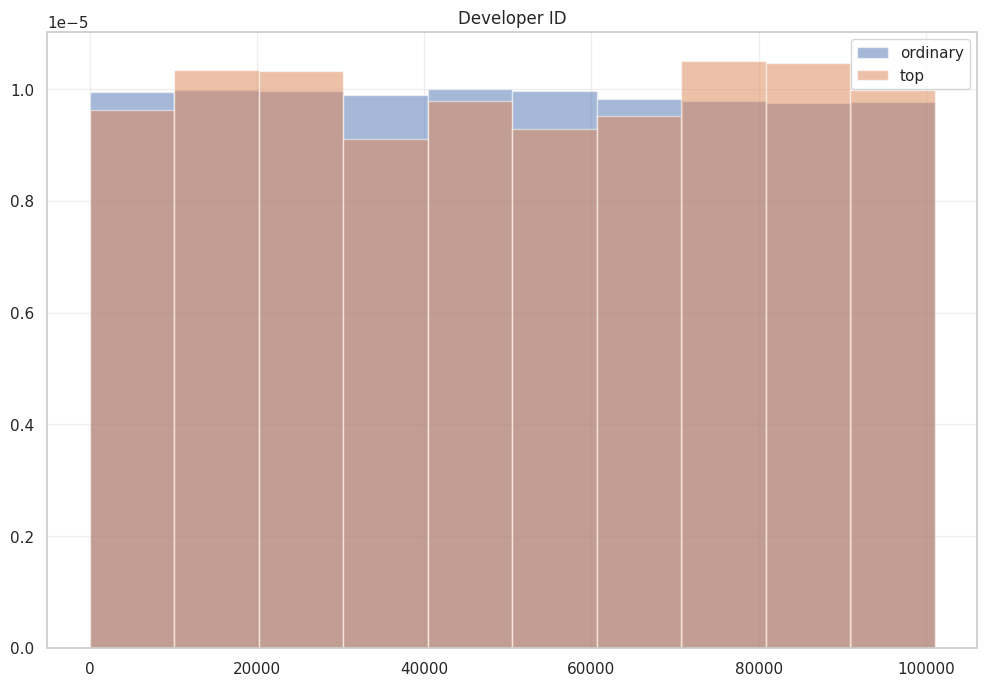

In [89]:
dist_plot('Developer ID', 'developer_id')

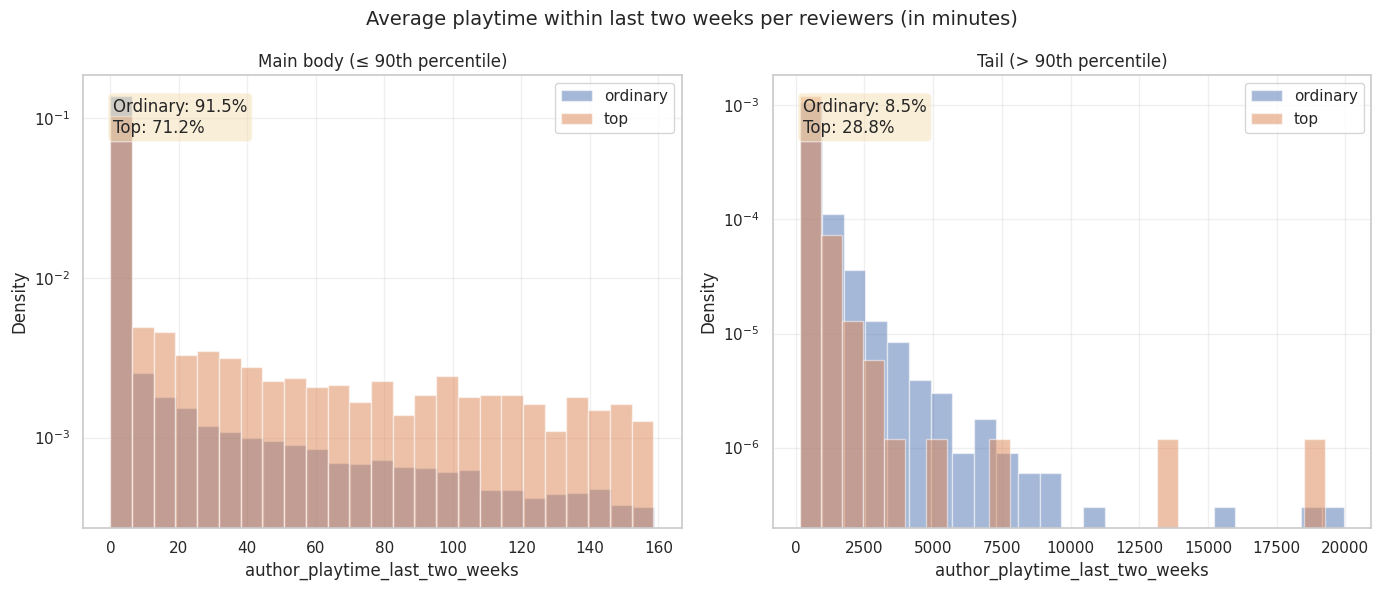

In [90]:
dist_plot_trimmed(
    'Average playtime within last two weeks per reviewers (in minutes)', 
    'author_playtime_last_two_weeks',
    bins=25,
    ylog=True,
)

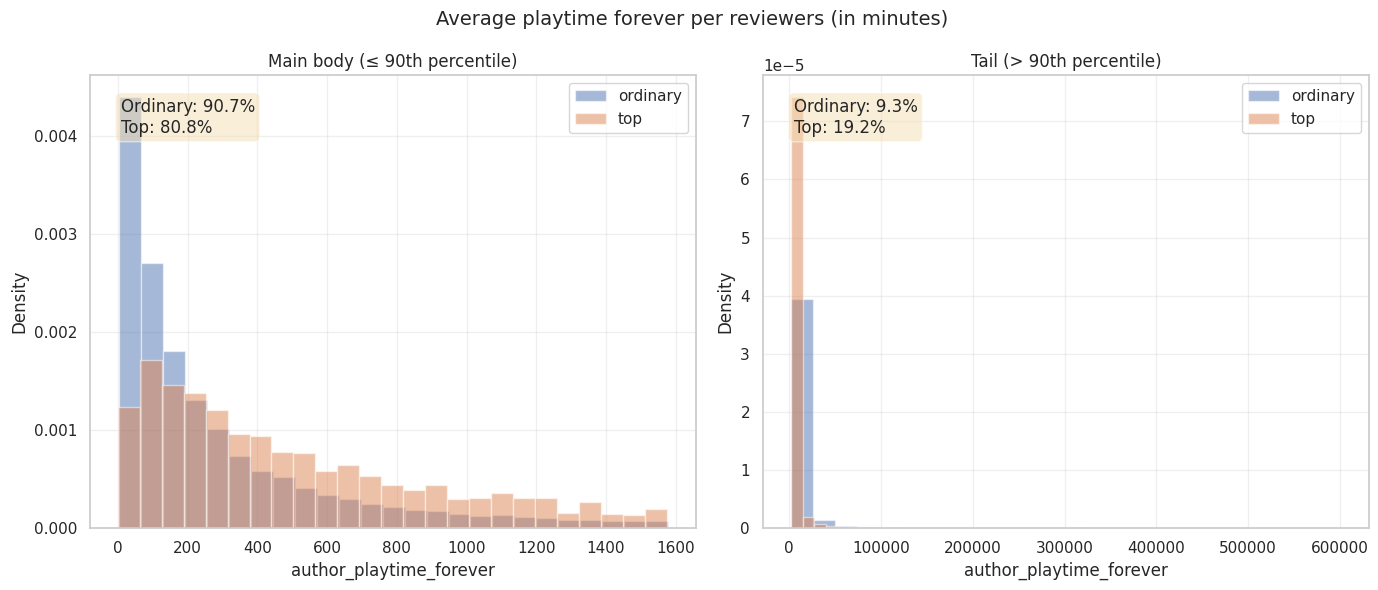

In [91]:
dist_plot_trimmed(
    'Average playtime forever per reviewers (in minutes)', 
    'author_playtime_forever',
    bins=25,
)

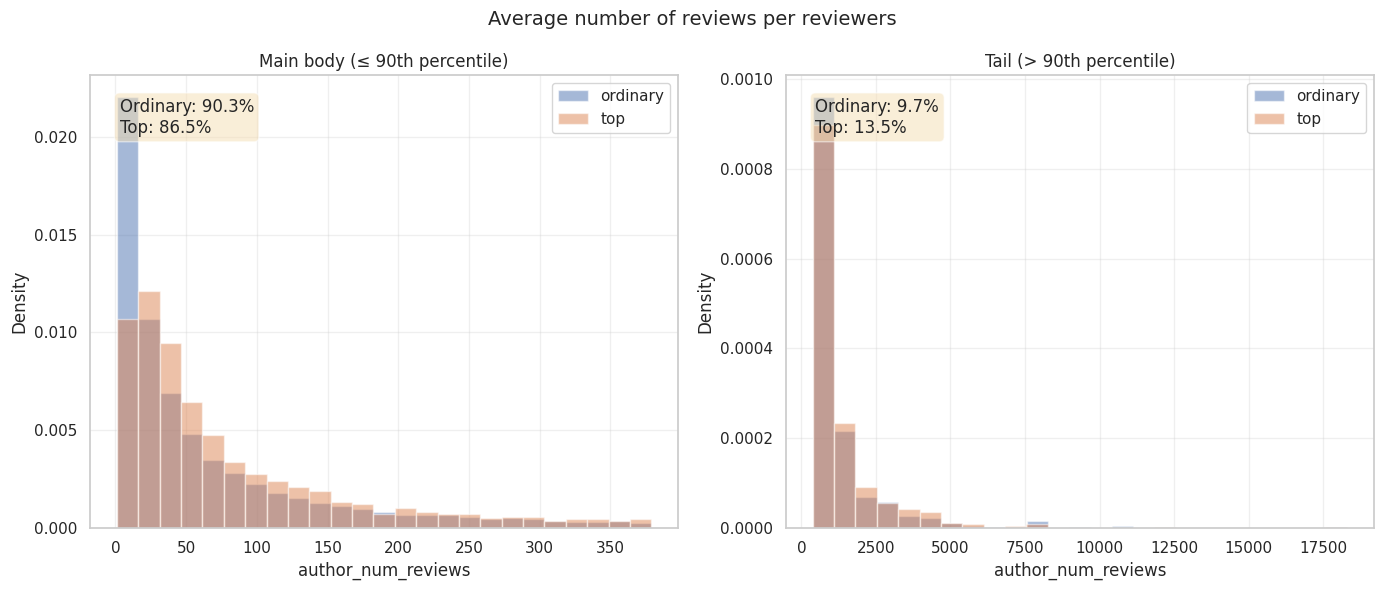

In [92]:
dist_plot_trimmed(
    'Average number of reviews per reviewers', 
    'author_num_reviews',
    bins=25,
)

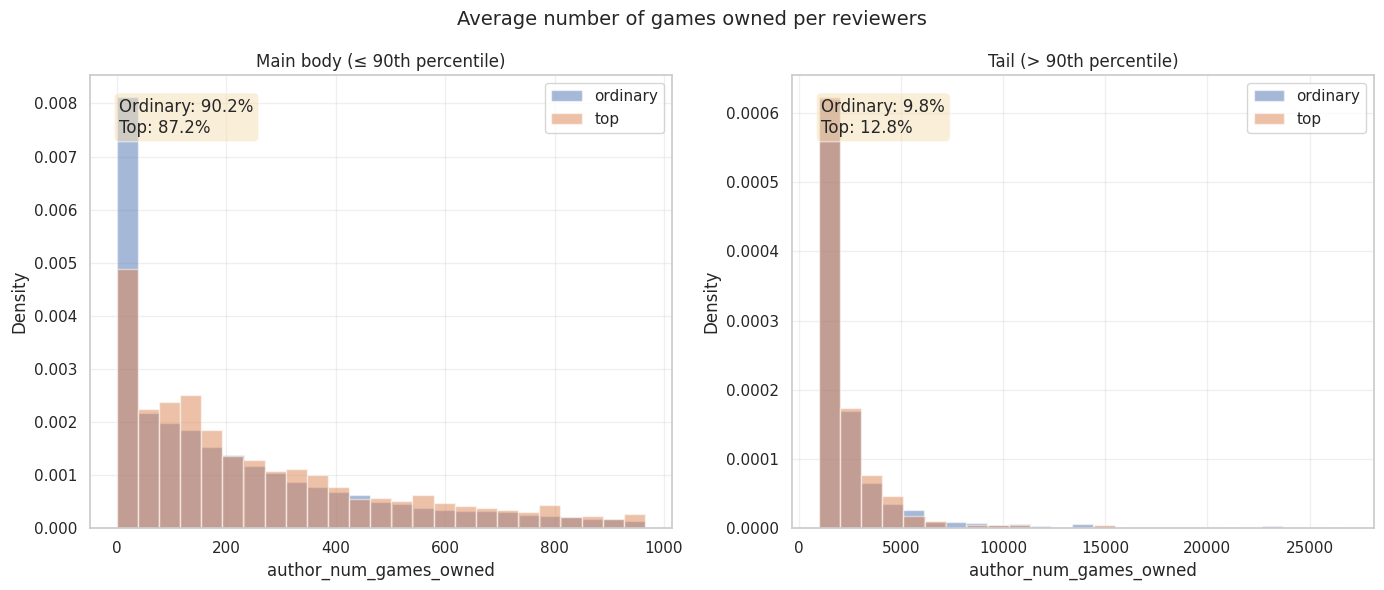

In [93]:
dist_plot_trimmed(
    'Average number of games owned per reviewers', 
    'author_num_games_owned',
    bins=25,
)

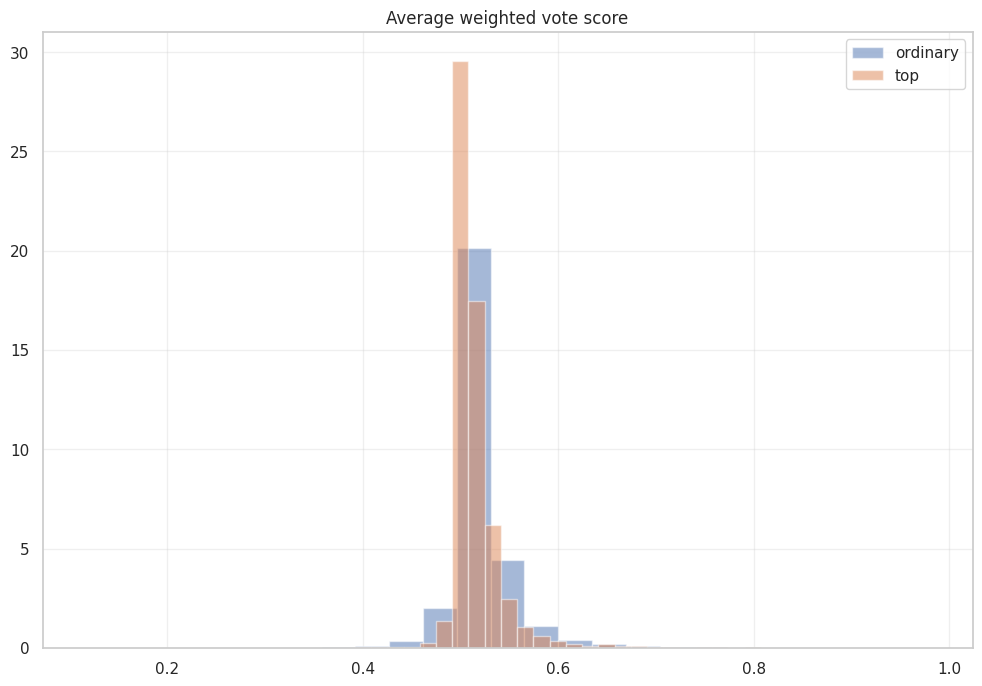

In [94]:
dist_plot(
    'Average weighted vote score', 
    'weighted_vote_score',
    bins=25,
)

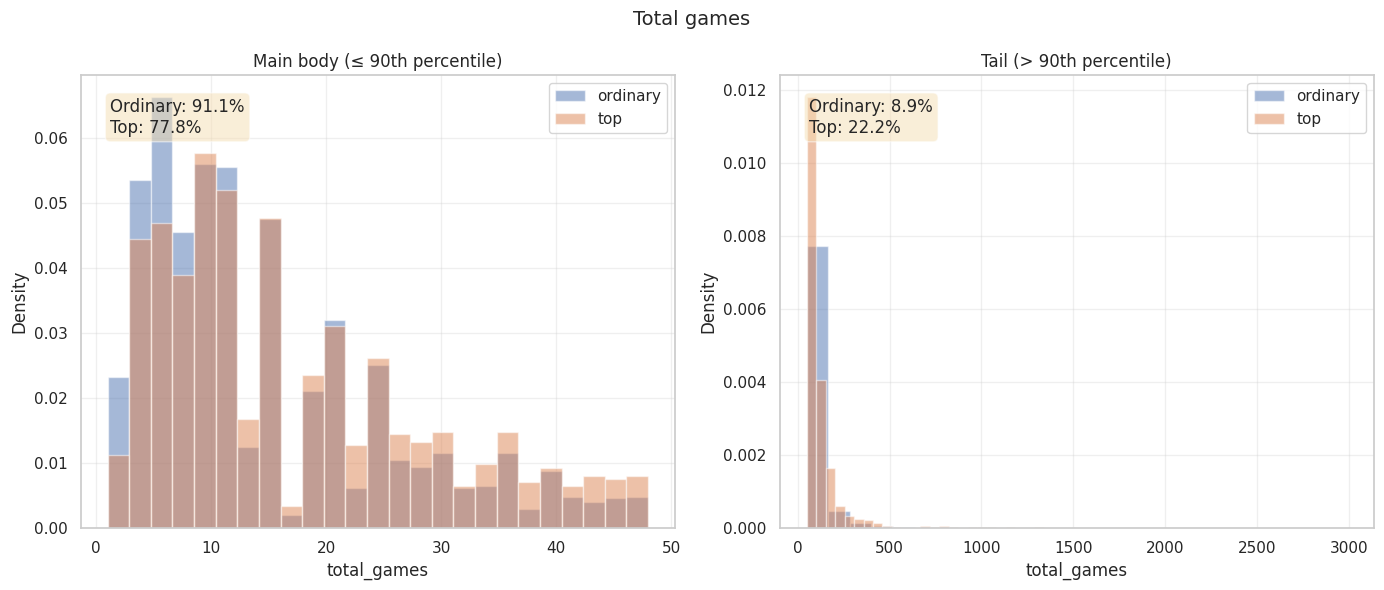

In [95]:
dist_plot_trimmed(
    'Total games', 
    'total_games',
    bins=25,
)

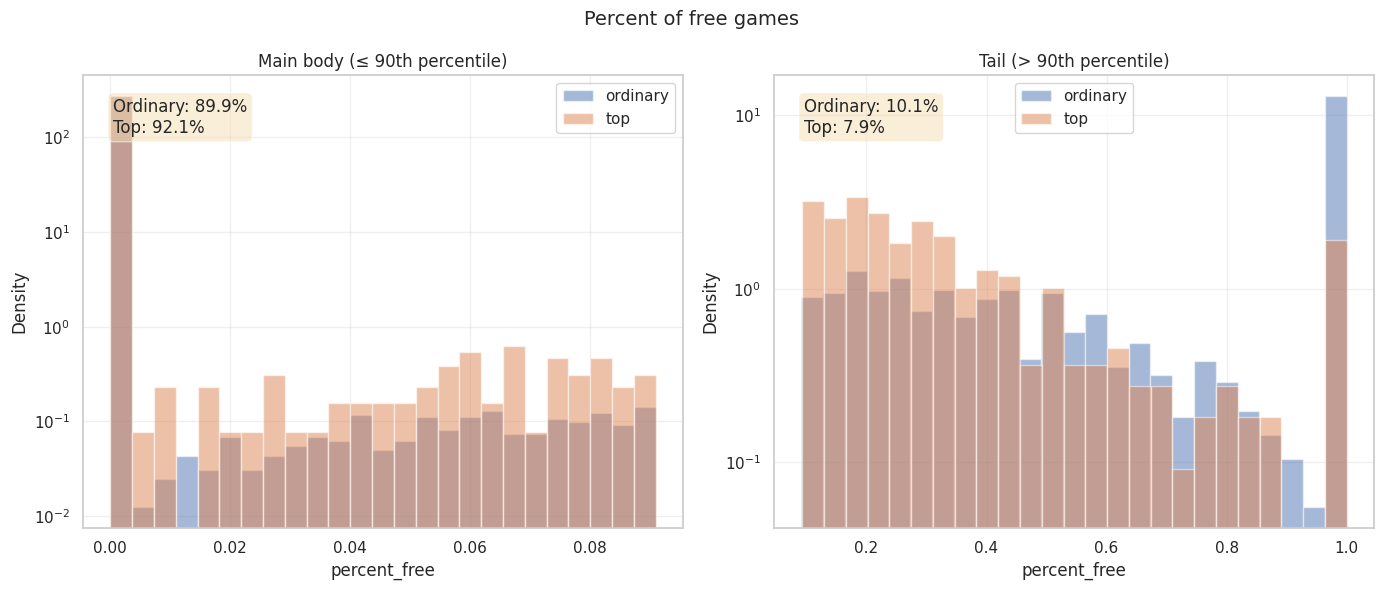

In [96]:
dist_plot_trimmed(
    'Percent of free games', 
    'percent_free',
    bins=25,
    ylog=True
)

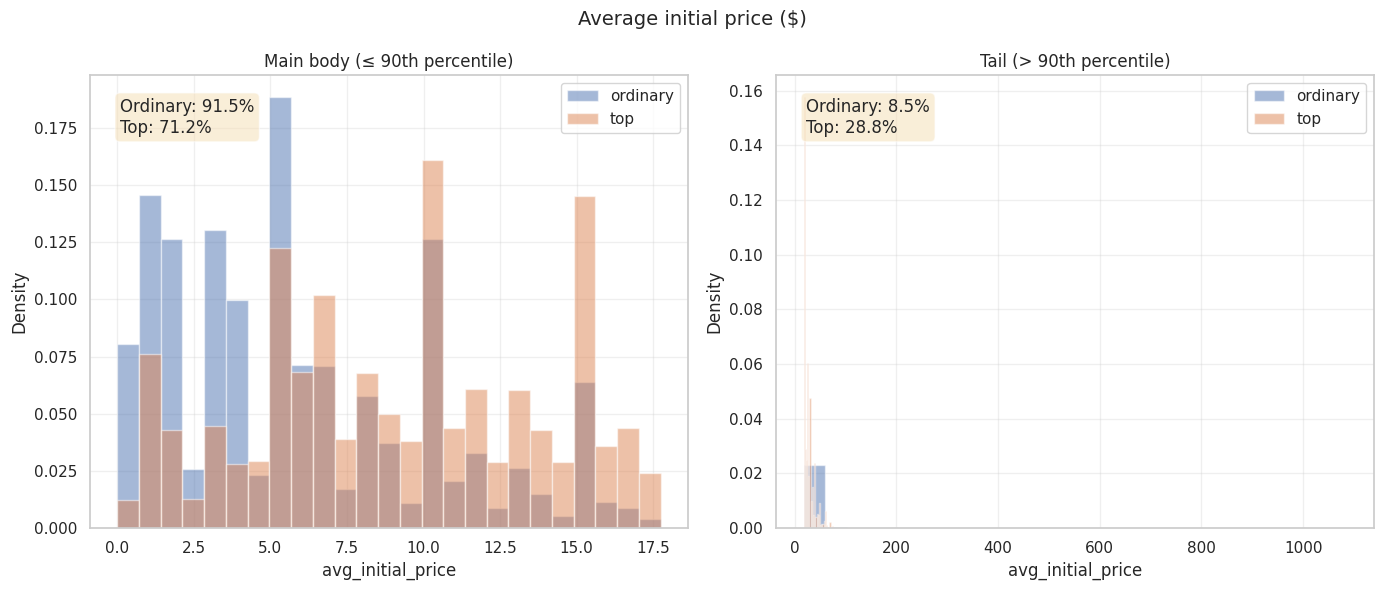

In [97]:
dist_plot_trimmed(
    'Average initial price ($)', 
    'avg_initial_price',
    bins=25,
)

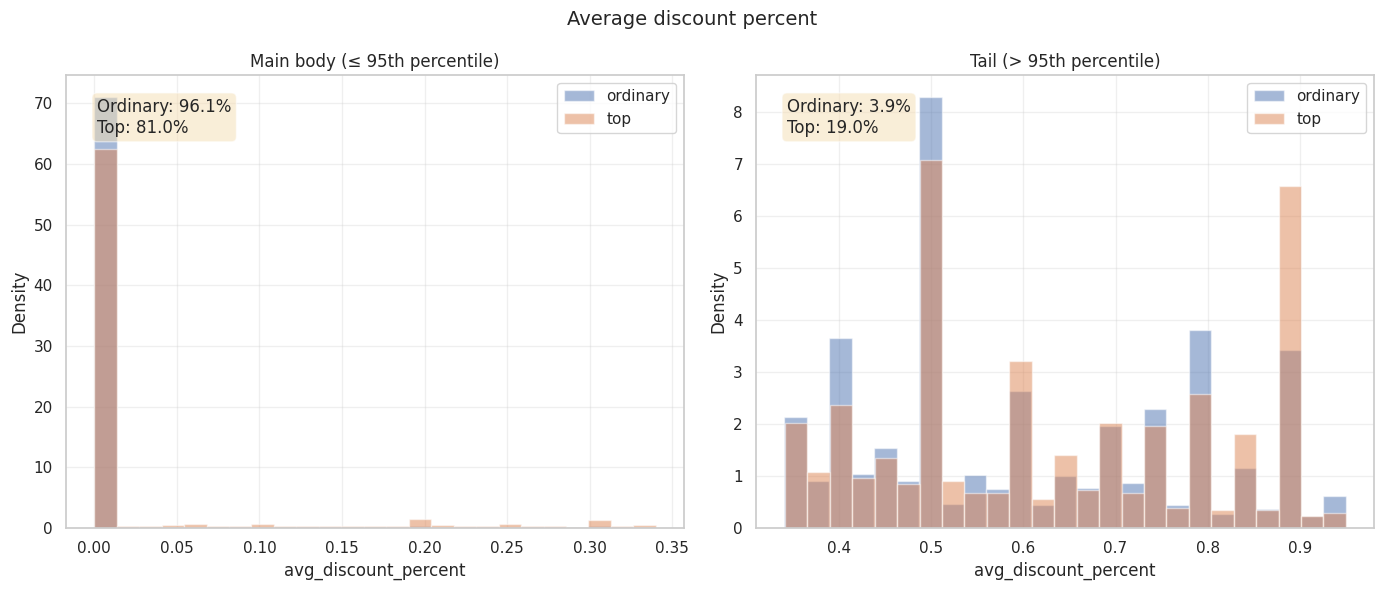

In [98]:
dist_plot_trimmed(
    'Average discount percent', 
    'avg_discount_percent',
    bins=25,
    percentile=95,
)

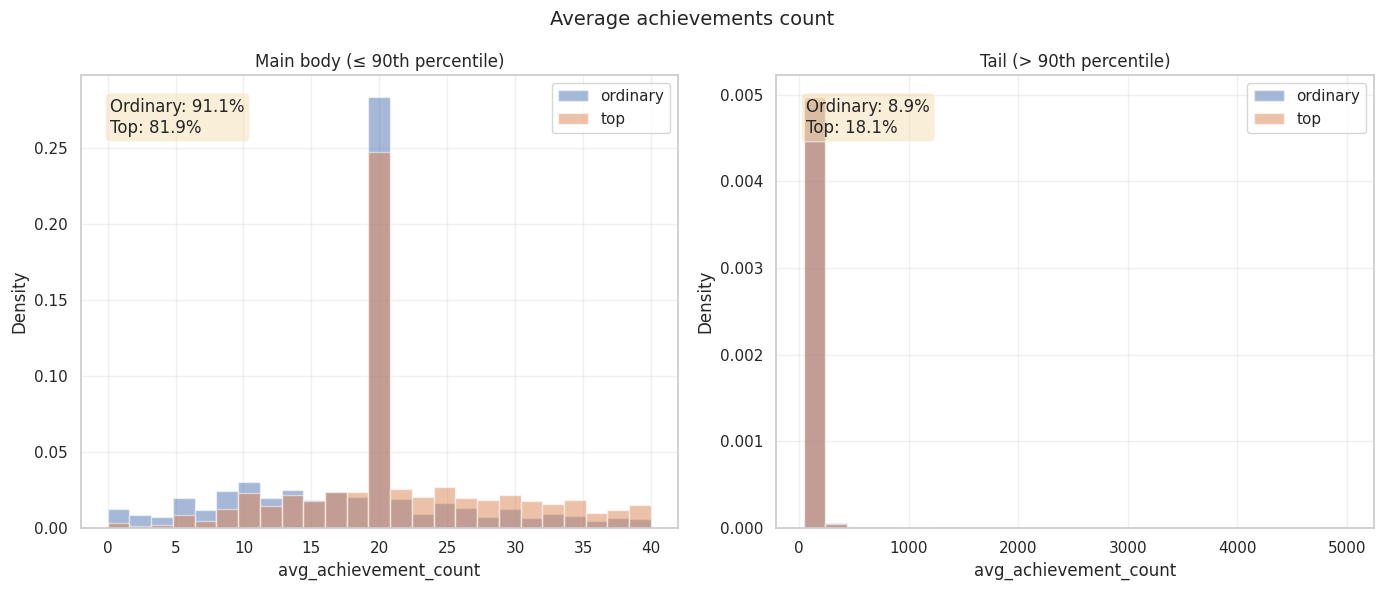

In [99]:
dist_plot_trimmed(
    'Average achievements count', 
    'avg_achievement_count',
    bins=25,
)

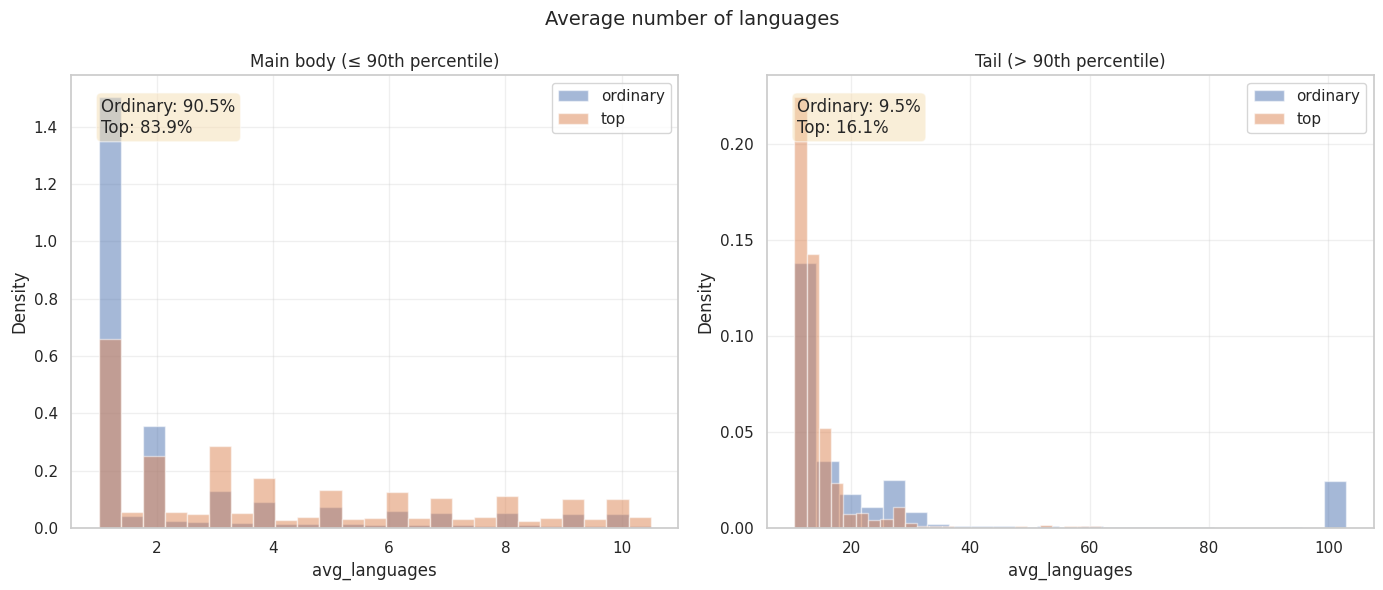

In [100]:
dist_plot_trimmed(
    'Average number of languages', 
    'avg_languages',
    bins=25,
)

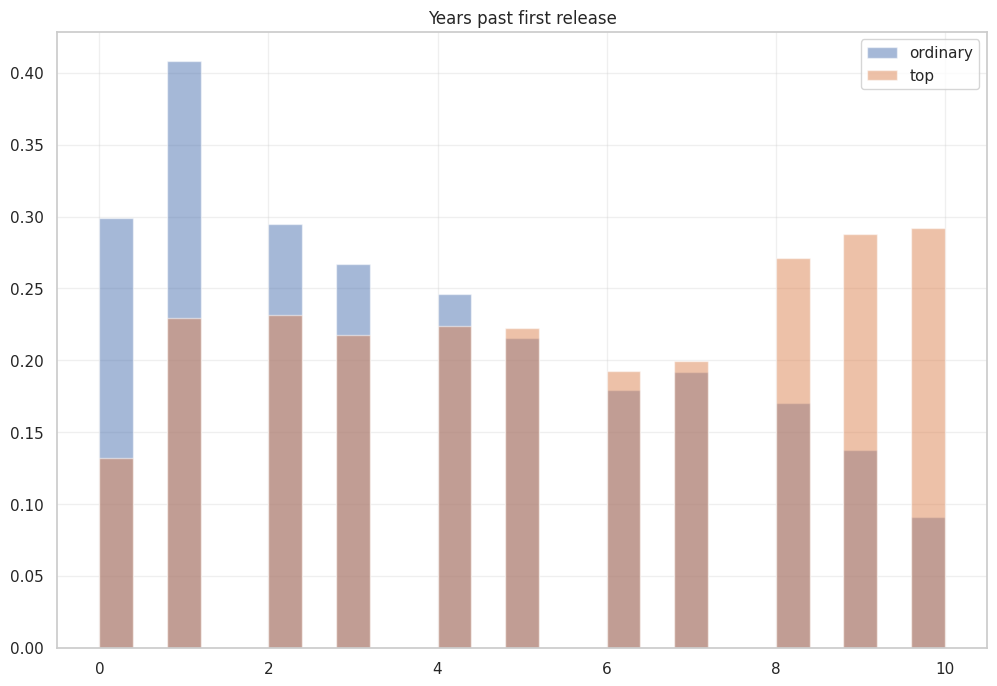

In [101]:
dist_plot(
    'Years past first release', 
    'years_past_first_release',
    bins=25,
)

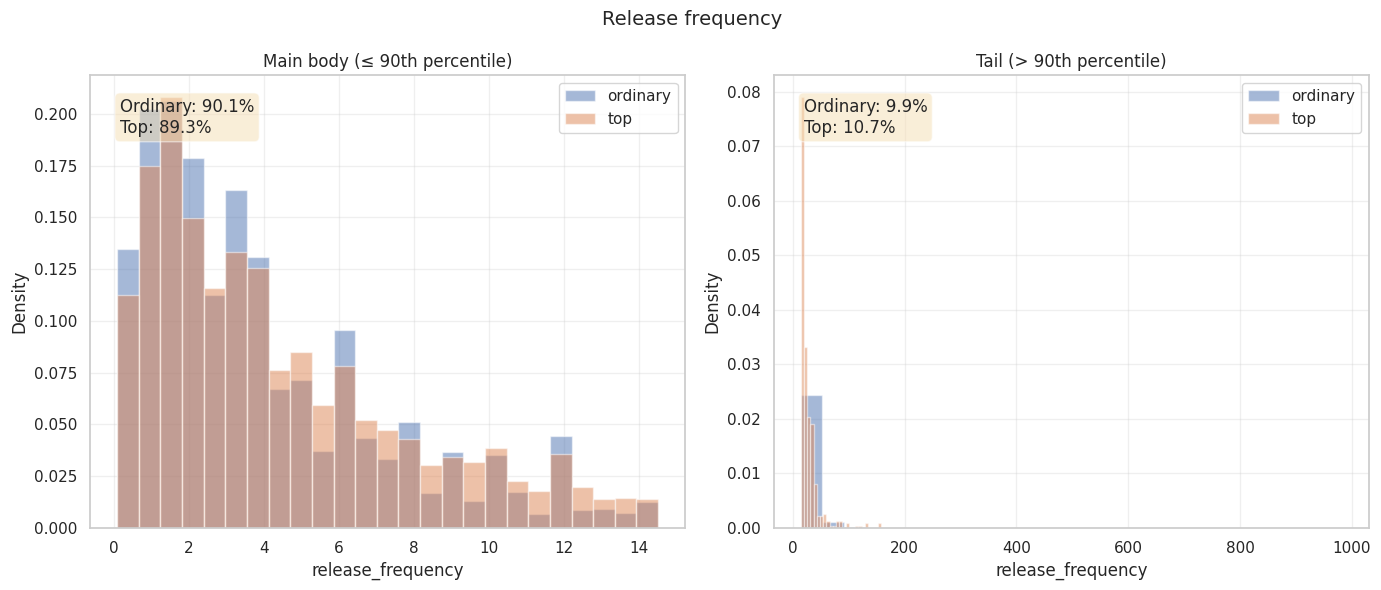

In [102]:
dist_plot_trimmed(
    'Release frequency', 
    'release_frequency',
    bins=25,
)

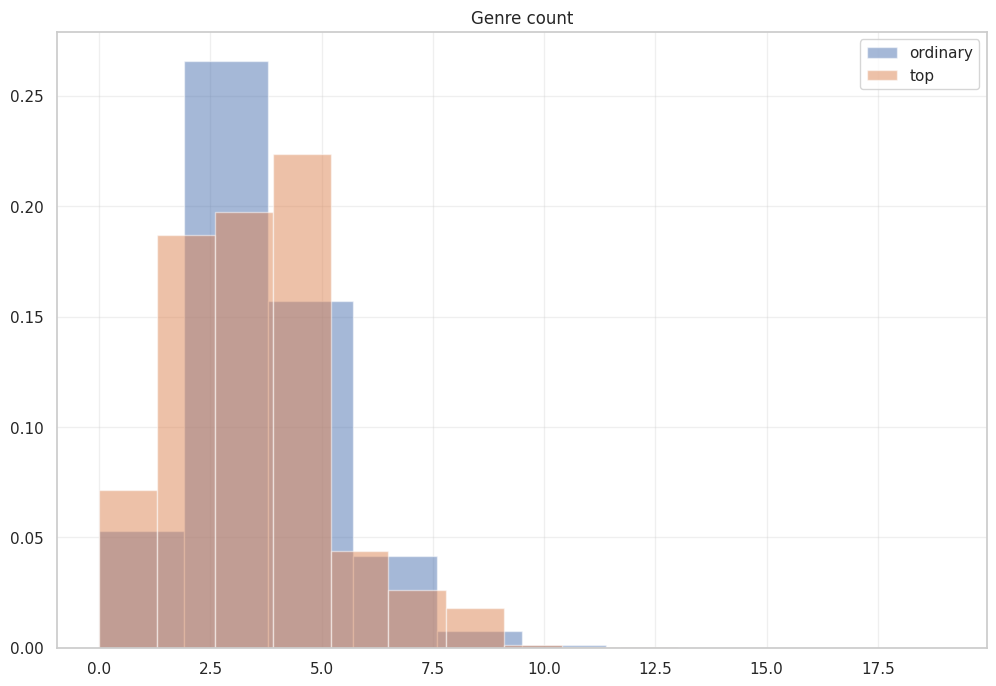

In [103]:
dist_plot(
    'Genre count', 
    'genre_count',
)

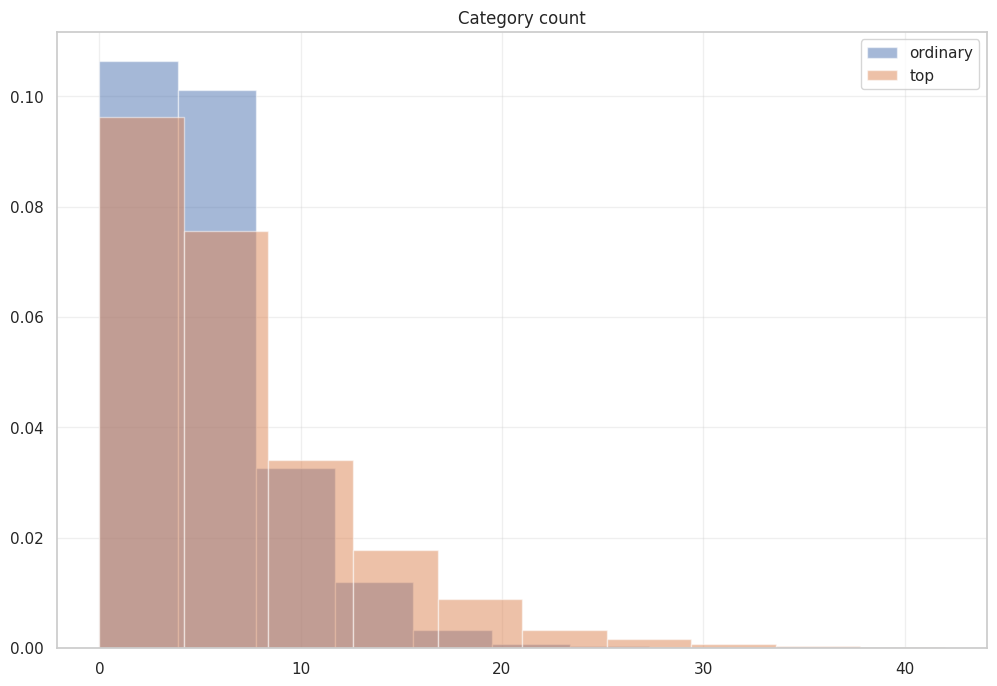

In [104]:
dist_plot(
    'Category count', 
    'category_count',
)

### Box Plots

<Axes: xlabel='is_top', ylabel='author_playtime_last_two_weeks'>

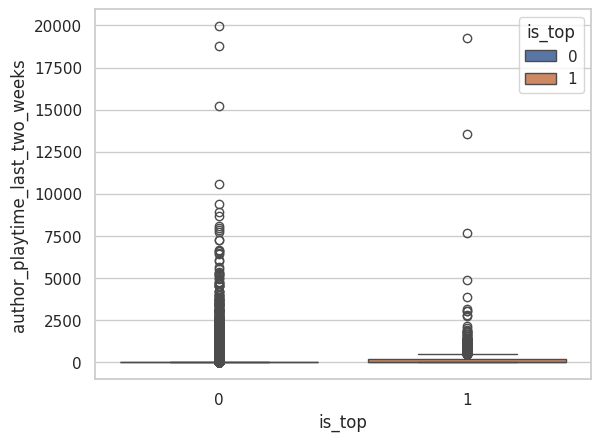

In [105]:
sns.boxplot(dev_stats, x='is_top', y='author_playtime_last_two_weeks', hue='is_top')

<Axes: xlabel='is_top', ylabel='author_playtime_forever'>

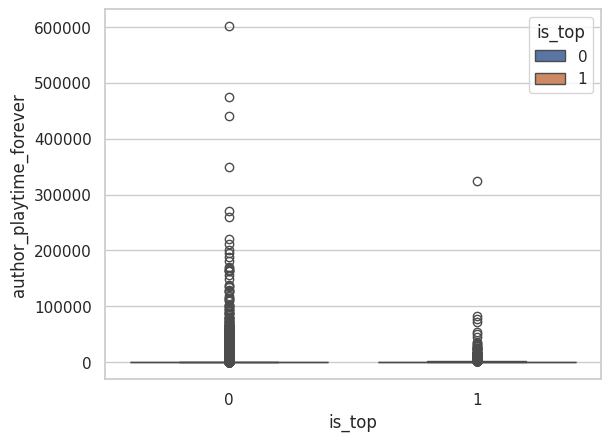

In [106]:
sns.boxplot(dev_stats, x='is_top', y='author_playtime_forever', hue='is_top')

<Axes: xlabel='is_top', ylabel='author_num_reviews'>

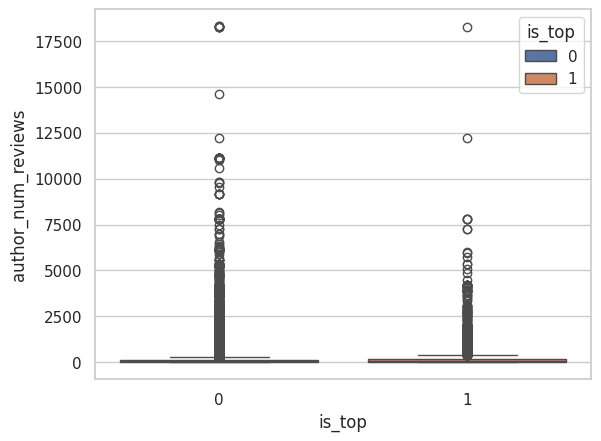

In [107]:
sns.boxplot(dev_stats, x='is_top', y='author_num_reviews', hue='is_top')

<Axes: xlabel='is_top', ylabel='author_num_games_owned'>

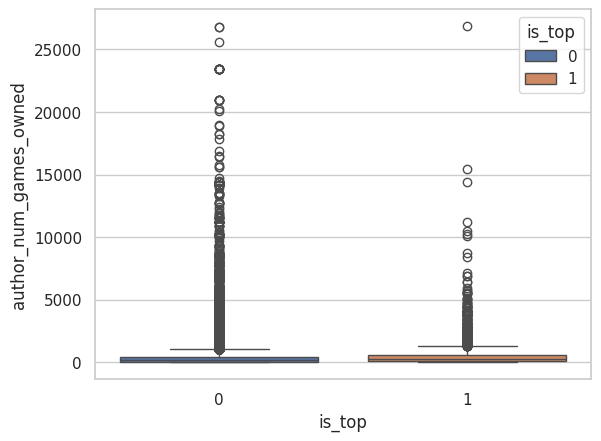

In [108]:
sns.boxplot(dev_stats, x='is_top', y='author_num_games_owned', hue='is_top')

<Axes: xlabel='is_top', ylabel='weighted_vote_score'>

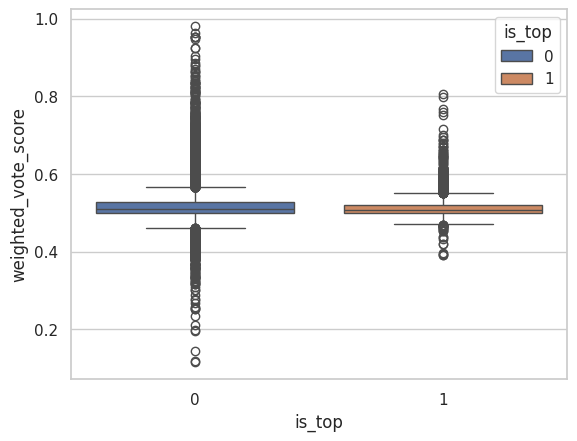

In [109]:
sns.boxplot(dev_stats, x='is_top', y='weighted_vote_score', hue='is_top')

<Axes: xlabel='is_top', ylabel='total_games'>

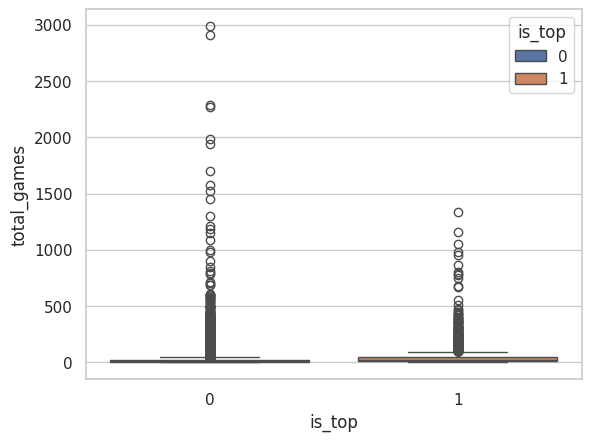

In [110]:
sns.boxplot(dev_stats, x='is_top', y='total_games', hue='is_top')

<Axes: xlabel='is_top', ylabel='percent_free'>

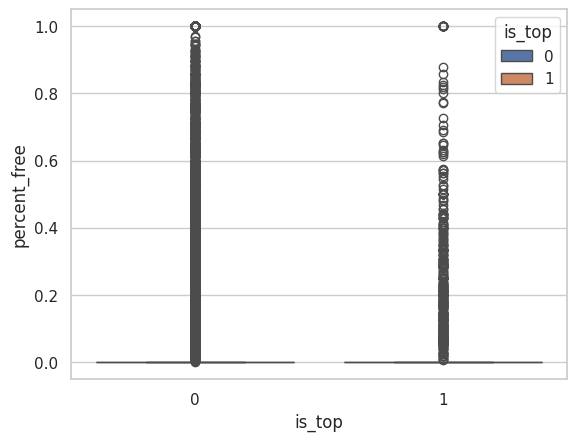

In [111]:
sns.boxplot(dev_stats, x='is_top', y='percent_free', hue='is_top')

<Axes: xlabel='is_top', ylabel='avg_initial_price'>

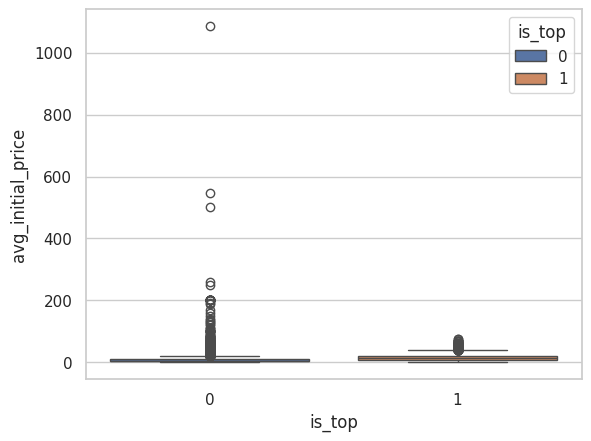

In [112]:
sns.boxplot(dev_stats, x='is_top', y='avg_initial_price', hue='is_top')

<Axes: xlabel='is_top', ylabel='avg_discount_percent'>

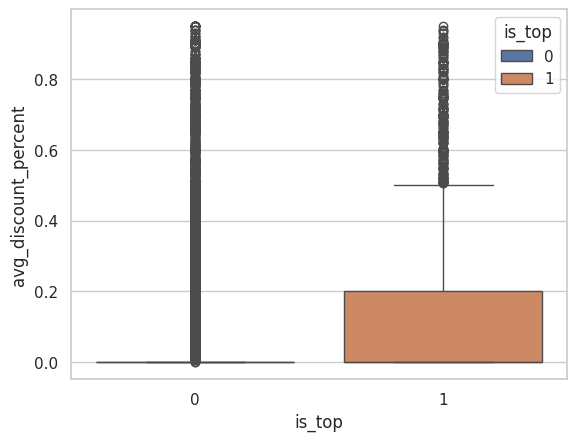

In [113]:
sns.boxplot(dev_stats, x='is_top', y='avg_discount_percent', hue='is_top')

<Axes: xlabel='is_top', ylabel='avg_achievement_count'>

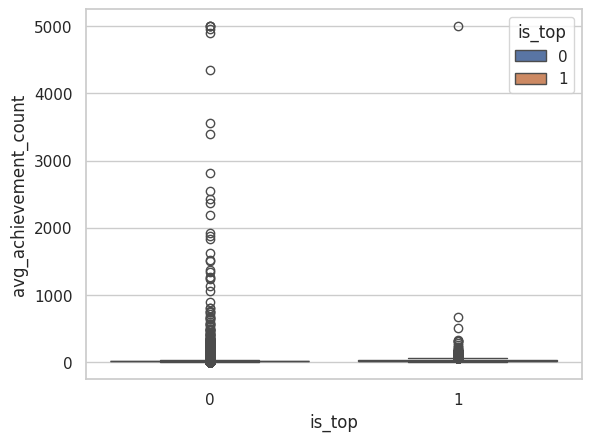

In [114]:
sns.boxplot(dev_stats, x='is_top', y='avg_achievement_count', hue='is_top')

<Axes: xlabel='is_top', ylabel='avg_languages'>

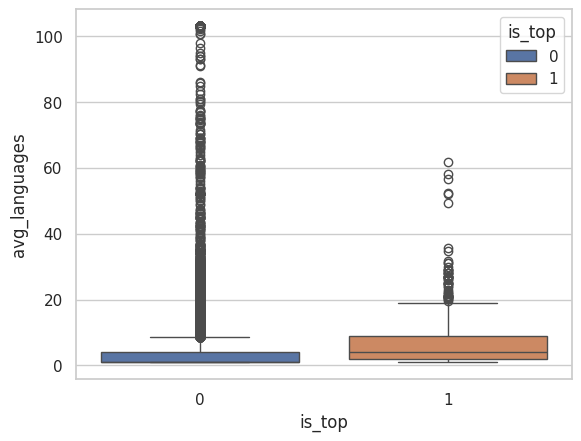

In [115]:
sns.boxplot(dev_stats, x='is_top', y='avg_languages', hue='is_top')

<Axes: xlabel='is_top', ylabel='years_past_first_release'>

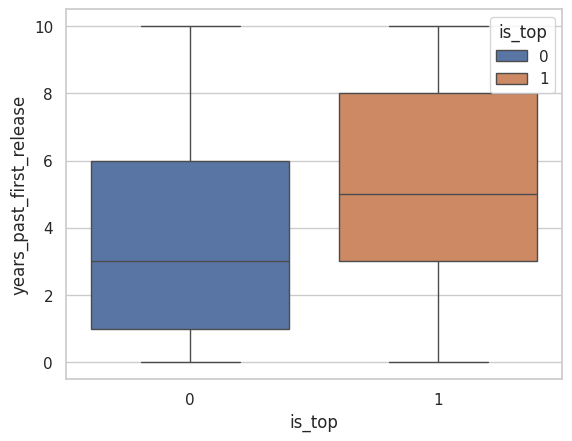

In [116]:
sns.boxplot(dev_stats, x='is_top', y='years_past_first_release', hue='is_top')

<Axes: xlabel='is_top', ylabel='release_frequency'>

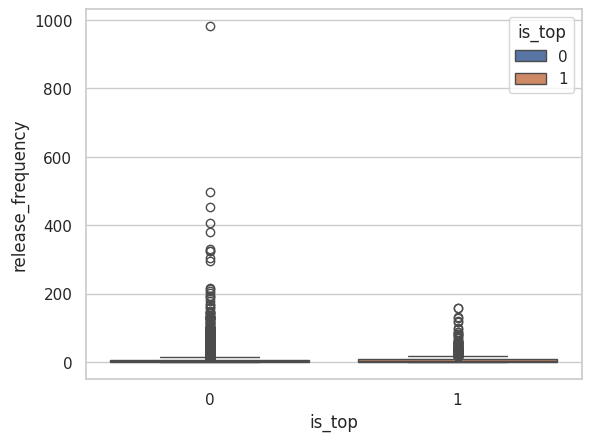

In [117]:
sns.boxplot(dev_stats, x='is_top', y='release_frequency', hue='is_top')

<Axes: xlabel='is_top', ylabel='genre_count'>

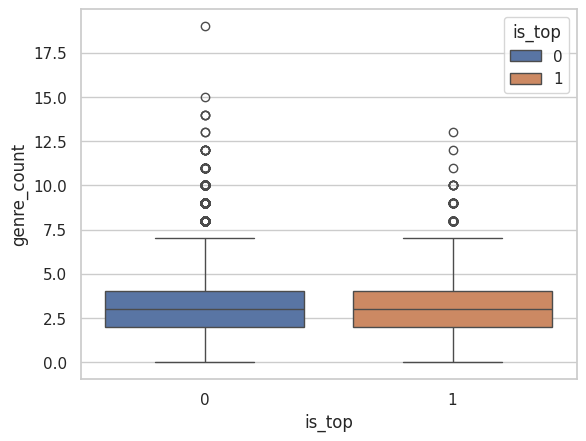

In [118]:
sns.boxplot(dev_stats, x='is_top', y='genre_count', hue='is_top')

<Axes: xlabel='is_top', ylabel='category_count'>

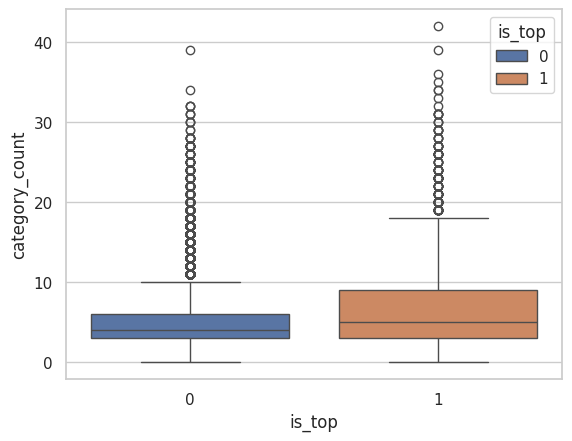

In [119]:
sns.boxplot(dev_stats, x='is_top', y='category_count', hue='is_top')

## Constructing

### Emerging Developers

The emerging developers are subject to selection and should not be present in the training set. These developers will be used for evaluating the modeling for compliance with the business success criteria.

In [120]:
dev_stats.columns

Index(['developer_id', 'author_playtime_last_two_weeks', 'author_num_reviews',
       'author_num_games_owned', 'author_playtime_forever',
       'weighted_vote_score', 'total_games', 'avg_initial_price',
       'avg_discount_percent', 'avg_achievement_count', 'avg_languages',
       'years_past_first_release', 'release_frequency', 'percent_free',
       'genre_count', 'category_count', 'is_top'],
      dtype='object')

In [121]:
emerging_dev_stats = dev_stats[dev_stats['years_past_first_release'] <= 3]
train_dev_stats = dev_stats[dev_stats['years_past_first_release'] > 3]

In [122]:
len(emerging_dev_stats), len(train_dev_stats)

(26330, 26950)

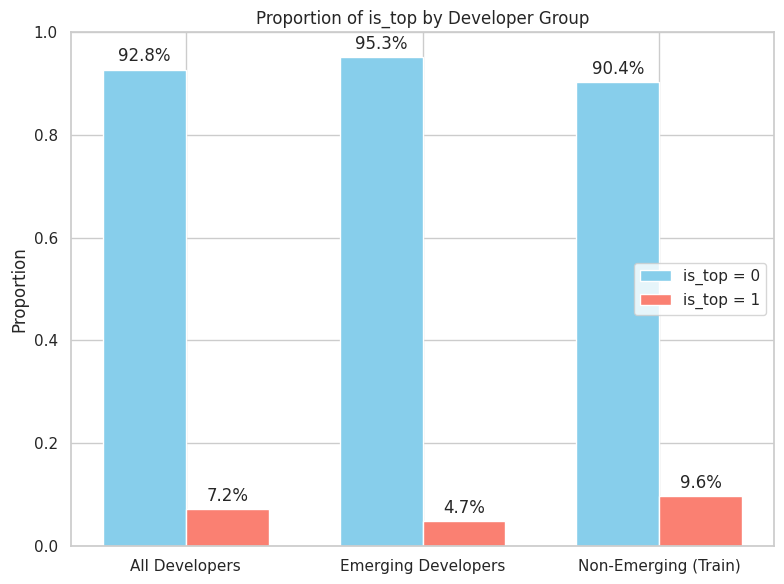

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate proportions of is_top = 0 and 1 for each group
def proportions(df):
    counts = df['is_top'].value_counts(normalize=True).sort_index()
    return counts[0], counts[1]  # proportion of 0, proportion of 1

all_prop0, all_prop1 = proportions(dev_stats)
emerging_prop0, emerging_prop1 = proportions(emerging_dev_stats)
train_prop0, train_prop1 = proportions(train_dev_stats)

# Data for plotting
groups = ['All Developers', 'Emerging Developers', 'Non‑Emerging (Train)']
prop0 = [all_prop0, emerging_prop0, train_prop0]
prop1 = [all_prop1, emerging_prop1, train_prop1]

x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars0 = ax.bar(x - width/2, prop0, width, label='is_top = 0', color='skyblue')
bars1 = ax.bar(x + width/2, prop1, width, label='is_top = 1', color='salmon')

ax.set_ylabel('Proportion')
ax.set_title('Proportion of is_top by Developer Group')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()

# Add percentage labels on bars
for bar in bars0:
    height = bar.get_height()
    ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Train-Test Split

The resulting dataframe of non-emerging developers should be split into train set (used for modeling) and test set (used for model evaluation) using stratification.

In [124]:
from sklearn.model_selection import train_test_split

test_size = 0.2

selected_columns = ['author_playtime_last_two_weeks', 'author_num_reviews',
                    'author_num_games_owned', 'author_playtime_forever',
                    'weighted_vote_score', 'total_games', 'avg_initial_price',
                    'avg_discount_percent', 'avg_achievement_count', 'avg_languages',
                    'years_past_first_release', 'release_frequency', 'percent_free',
                    'genre_count', 'category_count', 'is_top']

df_train, df_test = train_test_split(
    train_dev_stats[selected_columns],
    test_size=0.2,
    stratify=train_dev_stats['is_top'],
    random_state=0
)

In [125]:
len(df_train), len(df_test)

(21560, 5390)

In [126]:
round(df_train['is_top'].sum() / len(df_train), 3),\
round(df_test['is_top'].sum() / len(df_test), 3)

(np.float64(0.096), np.float64(0.096))

In [127]:
df_emerging = emerging_dev_stats[selected_columns]

In [128]:
df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)
df_emerging.to_csv('emerging.csv', index=False)

### PCA

In [129]:
y = df_train['is_top'].copy()

X = df_train.drop(columns=['is_top'])

In [130]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)

In [131]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [132]:
pca.explained_variance_ratio_

array([0.18794091, 0.09928761, 0.09591496, 0.08711976, 0.07468235,
       0.07186027, 0.06604482, 0.05975538, 0.05104429, 0.04618147,
       0.04269971, 0.04167042, 0.04005788, 0.03359909, 0.00214107])

In [133]:
X_2d = PCA(n_components=2).fit_transform(X_scaled)

data_2d = pd.DataFrame({
    'PCA1': X_2d[:, 0],
    'PCA2': X_2d[:, 1],
    'is_top': y
})

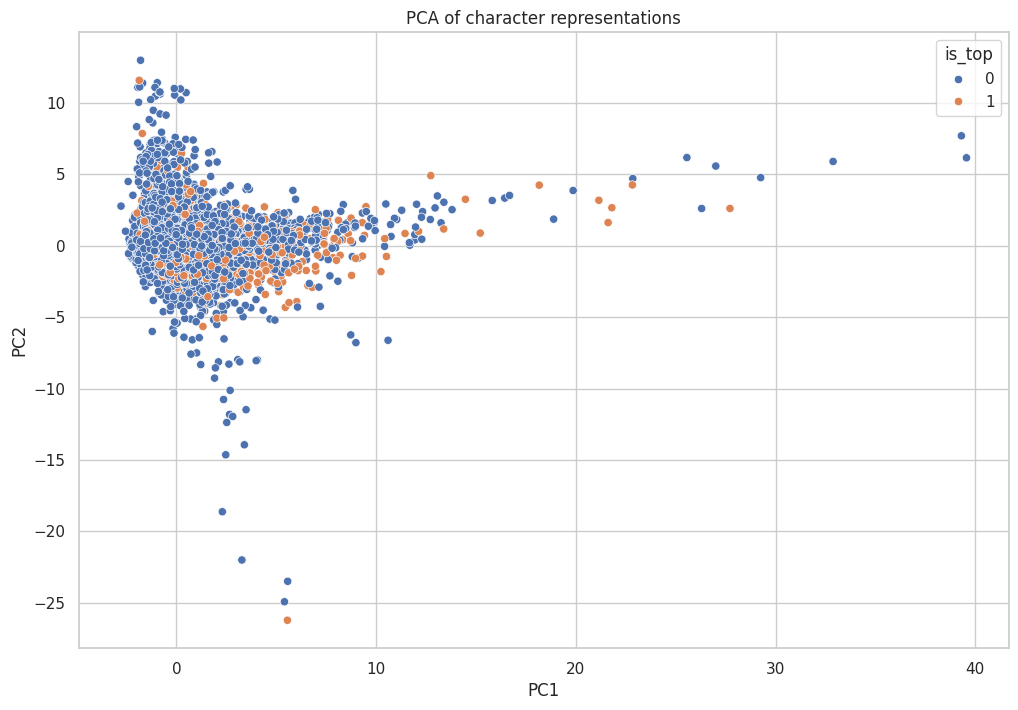

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data_2d, x='PCA1', y='PCA2', hue='is_top')
# plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of character representations')
plt.show()

### Clustering with DBSCAN

In [135]:
from sklearn.preprocessing import RobustScaler


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

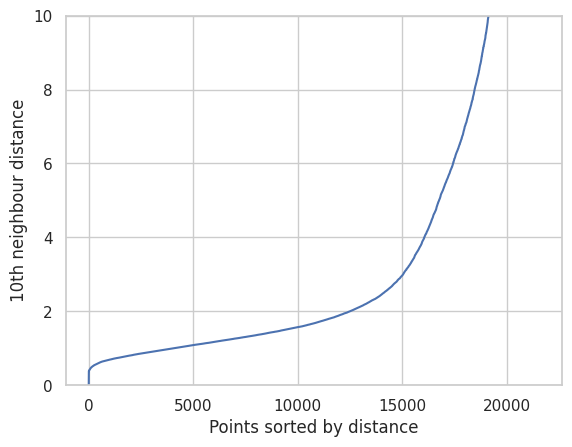

In [136]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neigh = NearestNeighbors(n_neighbors=10)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
# Sort distances to the 10th neighbour
k_dist = np.sort(distances[:, 9])
plt.plot(k_dist)
plt.xlabel('Points sorted by distance')
plt.ylabel('10th neighbour distance')

plt.ylim([0, 10])
plt.show()

In [137]:
from sklearn.cluster import DBSCAN

eps = 3   # based on k‑distance graph
min_samples = 12
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

In [138]:
X_aug = X.copy()

X_aug['cluster'] = labels   # labels from DBSCAN
X_aug['is_top'] = df_train['is_top']

In [139]:
cluster_summary = X_aug.groupby('cluster').agg(
    size=('is_top', 'count'),
    top_devs=('is_top', 'sum')
).reset_index()

cluster_summary['pct_of_total'] = cluster_summary['size'] / len(X_aug) * 100
cluster_summary['top_pct'] = cluster_summary['top_devs'] / cluster_summary['size'] * 100
cluster_summary.sort_values('top_pct', ascending=False)

,cluster,size,top_devs,pct_of_total,top_pct
0,-1,5945,1250,27.57,21.03
8,7,13,2,0.06,15.38
2,1,40,4,0.19,10.00
7,6,12,1,0.06,8.33
6,5,14,1,0.06,7.14
1,0,15427,819,71.55,5.31
5,4,19,1,0.09,5.26
3,2,45,0,0.21,0.00
4,3,33,0,0.15,0.00
9,8,12,0,0.06,0.00


In [140]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, labels)

np.float64(0.29248972612811114)

The analysis reveals that the developer space is mostly continuous, the points do not form high dense discrete clusters but are rather situated in the single region with outliers. The silhouette score is also critically low.

### Clustering with K-Means

In [141]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

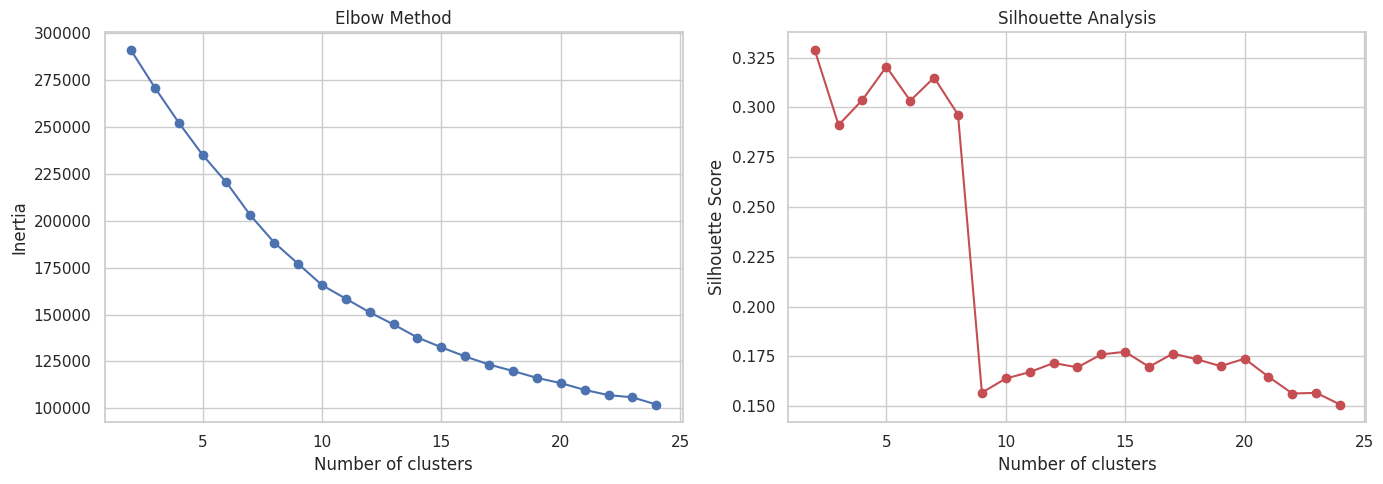

In [142]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 25)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
plt.tight_layout()
plt.show()

In [143]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [144]:
X_aug = X.copy()

X_aug['cluster'] = labels
X_aug['is_top'] = df_train['is_top']

In [145]:
cluster_summary = X_aug.groupby('cluster').agg(
    size=('is_top', 'count'),
    top_devs=('is_top', 'sum')
).reset_index()

cluster_summary['pct_of_total'] = cluster_summary['size'] / len(X_aug) * 100
cluster_summary['top_pct'] = cluster_summary['top_devs'] / cluster_summary['size'] * 100
cluster_summary.sort_values('top_pct', ascending=False)

,cluster,size,top_devs,pct_of_total,top_pct
0,0,1025,358,4.75,34.93
2,2,2726,548,12.64,20.10
1,1,559,53,2.59,9.48
3,3,15508,1083,71.93,6.98
4,4,1742,36,8.08,2.07


In [146]:
cluster_profiles = X_aug.groupby('cluster').median().round(2)
cluster_profiles

,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count,is_top
cluster,,,,,,,,,,,,,,,,
0,0.00,91.05,259.60,299.00,0.51,19.00,8.56,0.66,20.00,4.50,6.00,2.55,0.00,3.00,5.00,0.00
1,0.00,3049.00,4006.00,144.00,0.51,14.00,3.99,0.00,20.00,1.00,8.00,1.50,0.00,3.00,5.00,0.00
2,24.34,62.58,251.89,622.81,0.51,80.00,11.13,0.00,24.63,5.00,8.00,10.00,0.00,6.00,12.00,0.00
3,0.00,54.50,209.03,200.00,0.51,12.00,5.45,0.00,20.00,1.00,6.00,1.80,0.00,3.00,4.00,0.00
4,0.00,50.64,194.27,226.58,0.51,16.00,0.00,0.00,20.00,1.00,7.00,2.00,1.00,4.00,4.00,0.00


| Cluster | Assigned Name | Size | % of Total | Top % | Key Characteristics |
|--------|---------------|------|------------|-------|---------------------|
| **0** | Premium Discounters | 1,025 | 4.8% | **34.9%** | Moderate portfolio (19 games), high discount (66%), moderate price (\$8.6), moderate languages (4.5), no free games, 6 years active. High top concentration. |
| **2** | High‑Volume Diversified | 2,726 | 12.6% | **20.1%** | Very large portfolio (80 games), extremely high release frequency (10 games/year), moderate price (\$11.1), no discounts, high genre/category diversity (6/12), 8 years active. |
| **1** | Hardcore Niche | 559 | 2.6% | 9.5% | Extremely dedicated players (3,049 reviews per reviewer, 4,006 games owned), small portfolio (14 games), low price (\$4.0), few languages (1), low release frequency (1.5). |
| **3** | Average Indie | 15,508 | 71.9% | 7.0% | Small portfolio (12 games), low price (\$5.5), low diversity (3 genres, 1 language), low engagement, no free games. The typical indie developer. |
| **4** | Free‑to‑Play | 1,742 | 8.1% | 2.1% | All games free (100%), zero price, small portfolio (16 games), low engagement, low diversity, 7 years active. Very low top proportion. |

In [147]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, labels)

np.float64(0.3203962260707704)

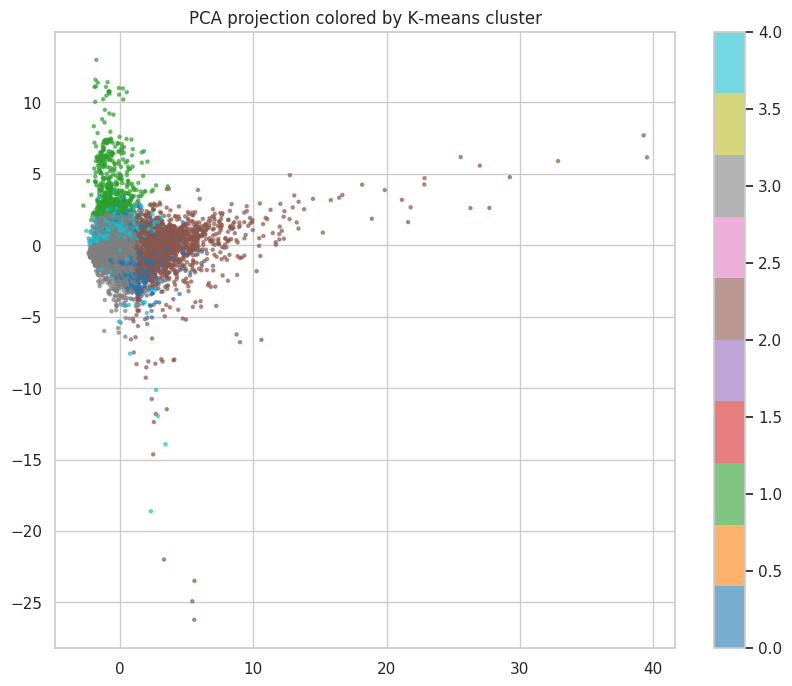

In [148]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=X_aug['cluster'], cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter)
plt.title('PCA projection colored by K‑means cluster')
plt.show()

### Augment Datasets

Fit K-means model on the train set and assign labels for the test set:

In [149]:
from sklearn.preprocessing import StandardScaler

X_train = df_train.drop(columns=['is_top'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [150]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_scaled)

In [151]:
X_test = df_test.drop(columns=['is_top'])

X_test_scaled = scaler.transform(X_test) # only transform

test_labels = kmeans.predict(X_test_scaled) # only transform

In [152]:
X_emerging = df_emerging.drop(columns=['is_top'])

X_emerging_scaled = scaler.transform(X_emerging) # only transform

emerging_labels = kmeans.predict(X_emerging_scaled) # only transform

In [153]:
df_train_aug = df_train.copy()
df_test_aug = df_test.copy()
df_emerging_aug = df_emerging.copy()

df_train_aug['cluster'] = train_labels
df_test_aug['cluster'] = test_labels
df_emerging_aug['cluster'] = emerging_labels

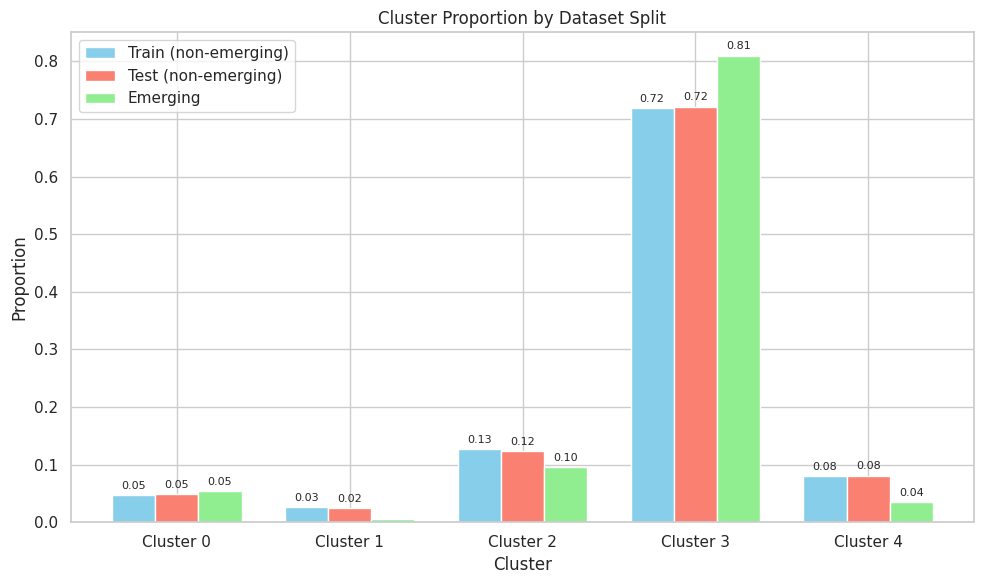

In [154]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Compute proportions for each cluster within each set
def cluster_proportions(df, cluster_col='cluster'):
    counts = df[cluster_col].value_counts(normalize=True).sort_index()
    return counts

train_prop = cluster_proportions(df_train_aug)
test_prop = cluster_proportions(df_test_aug)
emerging_prop = cluster_proportions(df_emerging_aug)

# Get all cluster labels (union of all sets)
all_clusters = sorted(set(train_prop.index) | set(test_prop.index) | set(emerging_prop.index))

# Align proportions (fill missing clusters with 0)
train_prop = train_prop.reindex(all_clusters, fill_value=0)
test_prop = test_prop.reindex(all_clusters, fill_value=0)
emerging_prop = emerging_prop.reindex(all_clusters, fill_value=0)

# Plot
x = np.arange(len(all_clusters))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, train_prop.values, width, label='Train (non‑emerging)', color='skyblue')
rects2 = ax.bar(x, test_prop.values, width, label='Test (non‑emerging)', color='salmon')
rects3 = ax.bar(x + width, emerging_prop.values, width, label='Emerging', color='lightgreen')

ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion')
ax.set_title('Cluster Proportion by Dataset Split')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in all_clusters])
ax.legend()

# Add value labels on bars (optional)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## Formatting

### Randomly Shuffle Train Dataset

In [155]:
from sklearn.utils import shuffle

df_train_aug = shuffle(df_train_aug, random_state=0)

### Format Clusters

Reconstruct table to replace the cluster column to one-hot encoding of clusters. Specifically, create columns `cluster_premium_discounters`, `cluster_hardcore_niche`, `cluster_high_volume_diversified`, `cluster_free_to_play` for clusters 0, 1, 2, and 4.

In [156]:
import pandas as pd

def encode_clusters(df, cluster_col='cluster', drop_original=True):
    """
    One‑hot encode clusters, creating columns only for clusters 0, 1, 2, 4,
    dropping the reference cluster 3 (Average Indie). Ensures all four columns exist.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a 'cluster' column with integer labels.
    cluster_col : str, default='cluster'
        Name of the cluster column.
    drop_original : bool, default=True
        Whether to drop the original cluster column.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with added binary indicator columns for clusters 0,1,2,4.
    """
    # List of clusters to keep (0, 1, 2, 4) – drop 3 as reference
    clusters_to_keep = [0, 1, 2, 4]
    
    # Mapping from cluster number to desired column name
    name_map = {
        0: 'cluster_premium_discounters',
        1: 'cluster_hardcore_niche',
        2: 'cluster_high_volume_diversified',
        4: 'cluster_free_to_play'
    }
    
    # Create binary indicators
    for cl in clusters_to_keep:
        col_name = name_map[cl]
        df[col_name] = (df[cluster_col] == cl).astype(int)
    
    # Drop the original cluster column if requested
    if drop_original:
        df = df.drop(columns=[cluster_col])
    
    return df

In [157]:
df_train_aug_encoded = encode_clusters(df_train_aug, cluster_col='cluster')
df_test_aug_encoded = encode_clusters(df_test_aug, cluster_col='cluster')
df_emerging_aug_encoded = encode_clusters(df_emerging_aug, cluster_col='cluster')

In [158]:
df_train_aug_encoded.to_csv('train_aug.csv', index=False)
df_test_aug_encoded.to_csv('test_aug.csv', index=False)
df_emerging_aug_encoded.to_csv('emerging_aug.csv', index=False)